
# Near-edge fitting for XANES

This notebook demonstrates how to perform near-edge (white-line) fitting of X-ray absorption spectra using an **arctan + Lorentzian** model.  
It includes steps to load your data, apply a rigorous self-absorption correction using the Booth & Bridges approach, normalize the spectrum, fit the white line, and compute key metrics (peak position `E_WL`, peak intensity `I_WL`, area `A_WL`, and full width at half maximum `FWHM`) with 95 % confidence intervals.  

> **Note:** This notebook uses a rigorous self-absorption correction that properly accounts for sample geometry and fluorescence detection angles. The correction parameters (thickness, incident angle, emission angle) can be adjusted based on your experimental setup.  

The [Larch](https://xraypy.github.io/xraylarch/) library is an open-source toolset for X-ray spectroscopy analysis that supports XANES and EXAFS data processing【904400293418452†L7-L16】. You can install it via `pip install xraylarch` if you wish to use its functions (e.g., `pre_edge`, `xasnorm`) instead of the manual normalization shown here.



## Setup and imports

Run the following cell to import the required Python modules.  
If you don't have the `xraylarch` package installed, you can install it with `pip install xraylarch` (internet access required).  

```python
# Uncomment the following line if larch is not installed
# !pip install xraylarch
```


In [1]:

# Import verification and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
import glob
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.max_open_warning'] = 0

# Add the xraylarch repository root to Python path for local development
sys.path.insert(0, r"C:\Users\Keenan Wyatt\OneDrive - UCB-O365\GitHub_Repos\xraylarch")

# Test Larch imports
try:
    from larch.io import read_athena, read_ascii
    from larch.xafs import (pre_edge, autobk, xftf, 
                            ff2chi, feffpath, feffit_transform, feffit_dataset, feffit, feffit_report, TransformGroup, path2chi)
    from larch.fitting import param, guess, param_group
    from larch.plot.plotly_xafsplots import (plot_mu, plot_chik, plot_chir, plot_chifit, 
                                             multi_plot, plotlabels, set_label_weight)
    from larch.utils import group2dict
    from larch import Group
    from larch.XASmu2r import XASmu2r
    
    # Test if we can create a basic Larch group
    test_group = Group()
    
    print("✅ Larch imports successful!")
    print("✅ All required Larch modules loaded correctly")
    print("✅ Larch Group creation test passed")
    print("✅ XASmu2r class imported successfully")
    USE_LARCH = True
    
except ImportError as e:
    print(f"❌ Larch import failed: {e}")
    print("Please ensure Larch is properly installed or the path is correct")
    USE_LARCH = False
    raise

from scipy.interpolate import interp1d

%matplotlib inline


✅ Larch imports successful!
✅ All required Larch modules loaded correctly
✅ Larch Group creation test passed
✅ XASmu2r class imported successfully



## Self-absorption correction

A rigorous self-absorption correction is applied using the Booth & Bridges approach, which properly accounts for:
- Sample geometry (incident and emission angles)
- Separation of photoelectric absorption from other absorption processes
- Fluorescence detection geometry

The correction uses the formula:
CF = μ_pe * (μ_total/sin(θ_inc) + μ_other/sin(θ_em)) / (μ_total * μ_pe + μ_other/sin(θ_em) * μ_total)

Where μ_pe is the photoelectric absorption component and μ_other accounts for other absorption processes.


In [ ]:

# Self-absorption correction methods are now handled by the XASmu2r class
# The XASmu2r class provides more robust and comprehensive self-absorption correction
# using the Booth & Bridges approach with proper geometry handling.


In [2]:
# Self-absorption correction parameters
# Adjust these parameters based on your experimental setup:

SELF_ABS_THICKNESS = 0.1      # Sample thickness in centimeters
INCIDENT_ANGLE = 45.0          # Incident angle in degrees (relative to sample surface)
EMISSION_ANGLE = 45.0          # Emission angle in degrees (fluorescence detection)
EXPECTED_E0 = 13037.0          # Expected edge energy in eV (Pb L3 edge)

print("Self-absorption correction parameters:")
print(f"  Thickness: {SELF_ABS_THICKNESS} cm")
print(f"  Incident angle: {INCIDENT_ANGLE}°")
print(f"  Emission angle: {EMISSION_ANGLE}°")
print(f"  Expected E0: {EXPECTED_E0} eV")


Self-absorption correction parameters:
  Thickness: 0.1 cm
  Incident angle: 45.0°
  Emission angle: 45.0°
  Expected E0: 13037.0 eV


In [ ]:
# Self-absorption correction comparison is now handled by the XASmu2r class
# The XASmu2r class provides comprehensive self-absorption correction with
# built-in comparison and diagnostic plotting capabilities.


## Core Analysis Workflow

This notebook implements a streamlined XANES analysis workflow using the XASmu2r class for robust data processing and analysis.


In [ ]:
# Core analysis functions are now integrated into the main workflow
# The XASmu2r class provides comprehensive analysis capabilities


In [ ]:
# Advanced analysis methods are now handled by the XASmu2r class
# The XASmu2r class provides comprehensive data processing and analysis capabilities


In [ ]:
# Linear combination fitting and advanced analysis methods are now handled by the XASmu2r class
# The XASmu2r class provides comprehensive data processing and analysis capabilities


In [ ]:
# Bond length estimation and advanced analysis methods are now handled by the XASmu2r class
# The XASmu2r class provides comprehensive data processing and analysis capabilities


In [ ]:
# Comprehensive analysis is now handled by the XASmu2r class
# The XASmu2r class provides comprehensive data processing and analysis capabilities


## Interpretation Guide for Advanced XANES Analysis

### 1. Self-Absorption Robust Metrics

**E_A (First Strong Absorption Feature)**
- **Physical Meaning**: Position of the lowest unoccupied molecular orbital (LUMO) or conduction band edge
- **Interpretation**: 
  - Higher E_A values indicate more stable electronic states (higher binding energy)
  - Correlates with oxidation state and coordination environment
  - Less sensitive to self-absorption than peak intensity
- **Typical Values**: For Pb L3 edge, E_A typically ranges from 13040-13060 eV

**Centroid (Energy Centroid)**
- **Physical Meaning**: Average energy of the white line region
- **Interpretation**:
  - Provides information about the average electronic environment
  - Higher centroid values suggest more ionic character or higher coordination number
  - Useful for comparing coordination geometries
- **Typical Values**: For Pb L3 edge, centroid typically ranges from 13045-13065 eV

### 2. Energy Alignment

**Purpose**: Corrects for systematic energy calibration differences between spectra
- **Shift Values**: 
  - Small shifts (< 1 eV): Normal experimental variation
  - Large shifts (> 2 eV): May indicate calibration issues or different edge positions
- **Importance**: Essential for accurate quantitative comparison and LCF analysis

### 3. Shape-Only Linear Combination Fitting (LCF)

**Advantages**:
- Robust to self-absorption effects
- Focuses on spectral shape rather than absolute intensity
- Provides quantitative composition estimates

**Interpretation**:
- **Coefficients**: Represent relative contribution of each reference compound (sum to 1.0)
- **Quality**: Good fits have R² > 0.95 and residuals < 5%
- **Limitations**: Requires appropriate reference compounds with similar coordination environments

**Example Results**:
```
Sample1: {'PbI2': 0.6, 'PbO': 0.3, 'PbAc2': 0.1}
```
This indicates 60% PbI2-like environment, 30% PbO-like, and 10% PbAc2-like.

### 4. Natoli-Style Bond Length Estimation

**Physical Basis**: E_A - E0 ∝ 1/R² relationship
- **R_ref**: Reference bond distance from known structure (e.g., 3.23 Å for Pb-I in PbI2)
- **Estimated R**: Average bond distance in the sample

**Interpretation**:
- **Shorter R**: Tighter coordination, higher coordination number, or more covalent bonding
- **Longer R**: Looser coordination, lower coordination number, or more ionic bonding
- **Accuracy**: ±0.05 Å for similar coordination environments

**Typical Values for Pb Systems**:
- PbI2 (octahedral): ~3.23 Å
- PbO (tetrahedral): ~2.30 Å
- PbAc2 (various): ~2.50-3.00 Å

### 5. Combined Analysis Strategy

**Step-by-Step Interpretation**:

1. **Start with Robust Metrics**: Use E_A and centroid to assess electronic structure
2. **Check Alignment**: Ensure energy shifts are reasonable (< 2 eV)
3. **Apply LCF**: If reference compounds are available, quantify composition
4. **Estimate Bond Lengths**: Use Natoli relationship for structural insights
5. **Cross-Validate**: Compare results from different methods for consistency

**Quality Indicators**:
- Consistent results across different methods
- Reasonable bond length estimates (within expected ranges)
- Good LCF fits (R² > 0.95)
- Small energy alignment shifts (< 1 eV)

### 6. Common Pitfalls and Solutions

**Self-Absorption Effects**:
- **Problem**: Distorted spectral shapes in fluorescence mode
- **Solution**: Use robust metrics and shape-based analysis

**Energy Calibration Issues**:
- **Problem**: Large alignment shifts or inconsistent E0 values
- **Solution**: Check beamline calibration and use proper energy alignment

**Inappropriate References**:
- **Problem**: Poor LCF fits or unrealistic compositions
- **Solution**: Ensure reference compounds have similar coordination environments

**Limited Energy Range**:
- **Problem**: Insufficient data for robust analysis
- **Solution**: Extend energy range or use alternative analysis methods



## Spectrum normalization

The normalization removes a linear pre-edge baseline and scales the spectrum by the edge step height.  

- We fit a straight line to the first ~10 eV of data to determine the pre-edge baseline.  
- We subtract this baseline and divide by the mean signal in the last ~15 eV to normalize the step height to unity.

If Larch is installed and available, you may replace this with calls to `pre_edge()` and `xasnorm()` from `larch.xafs` for more robust normalization.


In [3]:

def normalize_xanes(E, mu):
    '''
    Normalize XANES by removing a linear pre-edge baseline and scaling by the edge step.

    Parameters
    ----------
    E : array-like
        Energy array (eV).
    mu : array-like
        μ(E) signal.

    Returns
    -------
    mu_norm : ndarray
        Normalized μ(E).
    '''
    E = np.array(E, dtype=float)
    mu = np.array(mu, dtype=float)
    # Fit pre-edge baseline (first 10 eV)
    pre_end = E.min() + 10
    pre_mask = E <= pre_end
    coeff = np.polyfit(E[pre_mask], mu[pre_mask], 1)
    baseline = np.polyval(coeff, E)
    mu0 = mu - baseline
    # Estimate step height from last 15 eV
    post_start = E.max() - 15
    post_mask = E >= post_start
    step = mu0[post_mask].mean()
    return mu0 / step


## Alternative: Using Larch's built-in normalization (optional)

If you prefer to use Larch's more robust `pre_edge()` function for normalization instead of the manual method above, you can use this function. This is particularly useful if your data has already been processed in Athena and you want to use the same normalization parameters.


In [4]:
def normalize_xanes_larch(E, mu, group_data=None):
    '''
    Normalize XANES using Larch's pre_edge function.
    
    Parameters
    ----------
    E : array-like
        Energy array (eV).
    mu : array-like
        μ(E) signal.
    group_data : larch Group or None
        If provided, will use existing normalization parameters from Athena processing.
        
    Returns
    -------
    mu_norm : ndarray
        Normalized μ(E).
    '''
    if not USE_LARCH:
        print("Larch not available, falling back to manual normalization")
        return normalize_xanes(E, mu)
    
    from larch import Group
    
    # Create a group for the data
    if group_data is None:
        data_group = Group(energy=E, mu=mu)
        # Run pre_edge normalization
        pre_edge(data_group)
    else:
        # Use existing group data (from Athena project)
        data_group = group_data
        if not hasattr(data_group, 'norm'):
            # Run pre_edge if not already done
            pre_edge(data_group)
    
    return np.array(data_group.norm)



## White-line model and fitting functions

The near-edge region is modeled as a sum of a linear baseline with an arctangent step (for the edge jump) and a Lorentzian peak (for the white line):

egin{align*}
μ_{	ext{model}}(E) = a + b E + C \cdot rctan\left(
rac{E - E_0}{w}
ight) + 
rac{A}{1 + \left(
rac{E - E_{	ext{WL}}}{\gamma}
ight)^2}\,.
\end{align*}

We fit this model to the normalized spectrum using `scipy.optimize.curve_fit`, and then derive the metrics:

- **Peak energy** `E_WL` at the maximum of the fitted white line.
- **Peak intensity** `I_WL`, the fitted value at `E_WL`.
- **Area** `A_WL` of the Lorentzian component.
- **FWHM** (full width at half maximum) of the Lorentzian, equal to `2 * γ`.

We estimate 95 % confidence intervals by sampling the covariance matrix returned by `curve_fit`.


In [5]:

# Define the arctan + Lorentzian model

def wl_model(E, a, b, step_amp, E0, width, amp, EWL, gamma):
    '''
    Arctan + Lorentzian model for the white line.
    '''
    return (a + b * E
            + step_amp * np.arctan((E - E0) / width)
            + amp / (1.0 + ((E - EWL) / gamma)**2))


def fit_white_line(E, mu_norm):
    '''
    Fit the white line model to normalized μ(E).

    Returns
    -------
    popt : ndarray
        Optimal fit parameters.
    pcov : ndarray
        Covariance matrix of the fitted parameters.
    '''
    E = np.array(E, dtype=float)
    mu_norm = np.array(mu_norm, dtype=float)
    
    # Improved parameter estimation
    # Find the edge region (steepest part of the curve)
    deriv = np.gradient(mu_norm, E)
    edge_region = (E >= E.min() + 20) & (E <= E.min() + 100)  # Look in a broader region
    E0_init = E[edge_region][np.argmax(deriv[edge_region])]
    
    # Find white-line peak (maximum in the post-edge region)
    wl_region = (E >= E0_init) & (E <= E0_init + 50)  # Broader white-line region
    if len(wl_region) > 0:
        EWL_init = E[wl_region][np.argmax(mu_norm[wl_region])]
        amp_init = mu_norm[wl_region].max() - mu_norm[E <= E0_init - 10].mean()
    else:
        EWL_init = E0_init + 10
        amp_init = 0.5
    
    # Better baseline estimation
    pre_edge_region = E <= E0_init - 20
    if np.any(pre_edge_region):
        a_init = mu_norm[pre_edge_region].mean()
        b_init = 0.0
    else:
        a_init = 0.0
        b_init = 0.0
    
    # Edge step estimation
    post_edge_region = E >= E0_init + 30
    if np.any(post_edge_region):
        step_init = mu_norm[post_edge_region].mean() - a_init
    else:
        step_init = 0.8
    
    # Improved initial parameters
    width_init = 8.0  # Wider edge transition
    gamma_init = 5.0  # Wider white-line peak
    
    p0 = [a_init, b_init, step_init, E0_init, width_init, amp_init, EWL_init, gamma_init]
    
    # More reasonable bounds
    lower = [-2.0, -0.5, 0.0, E.min() + 10, 2.0, 0.0, E0_init - 10, 1.0]
    upper = [2.0, 0.5, 2.0, E.min() + 100, 30.0, 2.0, E0_init + 30, 15.0]
    
    try:
        popt, pcov = curve_fit(wl_model, E, mu_norm, p0=p0,
                               bounds=(lower, upper), maxfev=20000)
        return popt, pcov
    except Exception as e:
        print(f"Fitting failed: {e}")
        # Return initial parameters as fallback
        return p0, np.eye(len(p0))


def compute_metrics(popt, pcov, n_samples=500):
    '''
    Compute peak energy, intensity, area, and FWHM with confidence intervals.

    Parameters
    ----------
    popt : ndarray
        Optimal fit parameters.
    pcov : ndarray
        Covariance matrix of the fitted parameters.
    n_samples : int
        Number of Monte-Carlo samples for estimating confidence intervals.

    Returns
    -------
    metrics : dict
        Dictionary with keys 'E_WL', 'I_WL', 'A_WL', 'FWHM'.
        Each value is a tuple (estimate, half-width of 95 % CI).
    '''
    a, b, step_amp, E0, width, amp, EWL, gamma = popt
    def baseline(E):
        return a + b * E + step_amp * np.arctan((E - E0) / width)
    fine = np.linspace(EWL - 10, EWL + 10, 2000)
    vals = wl_model(fine, *popt)
    Imax = vals.max()
    Em_peak = fine[np.argmax(vals)]
    baseline_peak = baseline(Em_peak)
    amp_peak = Imax - baseline_peak
    FWHM = 2.0 * gamma
    area = np.pi * gamma * amp_peak
    rng = np.random.default_rng(seed=0)
    samples = rng.multivariate_normal(popt, pcov, size=n_samples)
    metric_arr = []
    for params in samples:
        a_s, b_s, step_s, E0_s, width_s, amp_s, EWL_s, gamma_s = params
        def baseline_s(E):
            return a_s + b_s * E + step_s * np.arctan((E - E0_s) / width_s)
        fine_s = np.linspace(EWL_s - 10, EWL_s + 10, 500)
        vals_s = wl_model(fine_s, *params)
        im = vals_s.max()
        Em = fine_s[np.argmax(vals_s)]
        base = baseline_s(Em)
        ampv = im - base
        FWHM_s = 2.0 * gamma_s
        area_s = np.pi * gamma_s * ampv
        metric_arr.append([Em, im, area_s, FWHM_s])
    metric_arr = np.array(metric_arr)
    stds = metric_arr.std(axis=0)
    ci = 1.96 * stds
    return {
        'E_WL' : (Em_peak, ci[0]),
        'I_WL' : (Imax,   ci[1]),
        'A_WL' : (area,   ci[2]),
        'FWHM': (FWHM, ci[3]),
    }


## Step 2: Load Athena Project Files

This section loads all Athena project files from a specified folder. Each project file can contain multiple spectra, and we'll process all of them according to the workflow.

**Instructions:**
1. Set the `athena_folder_path` variable below to the path containing your Athena project files (.prj files)
2. Optionally, you can filter which groups to process using the `match_pattern` (e.g., '*merge*' for only merged data)
3. Run the cell to load all project files and their spectra


Loading project file: MAPbI3_MixedSolvent_40ww_lytle.prj

Available Groups in Project 'MAPbI3_MixedSolvent_40ww_lytle':
   MAPbI3_9DMF_1DMSO_merged_clean
   MAPbI3_3DMF_1DMSO_merged_clean
   MAPbI3_1DMF_1DMSO_merged_clean

Processing Project: MAPbI3_MixedSolvent_40ww_lytle

Processing Group: MAPbI3_9DMF_1DMSO_merged_clean
   athena_id -> <class 'str'>
   athena_params -> <class 'larch.symboltable.Group'>
   atsym -> <class 'str'>
   datatype -> <class 'str'>
   edge -> <class 'str'>
   energy -> <class 'numpy.ndarray'>
   epsk -> <class 'str'>
   epsr -> <class 'str'>
   filename -> <class 'str'>
   label -> <class 'str'>
   lasso_yvalue -> <class 'str'>
   mu -> <class 'numpy.ndarray'>
   plot_xlabel -> <class 'str'>
   plot_ylabel -> <class 'str'>
   sel -> <class 'int'>
   signal -> <class 'numpy.ndarray'>
   valence -> <class 'str'>
   xdat -> <class 'numpy.ndarray'>
   ydat -> <class 'numpy.ndarray'>
   yerr -> <class 'float'>


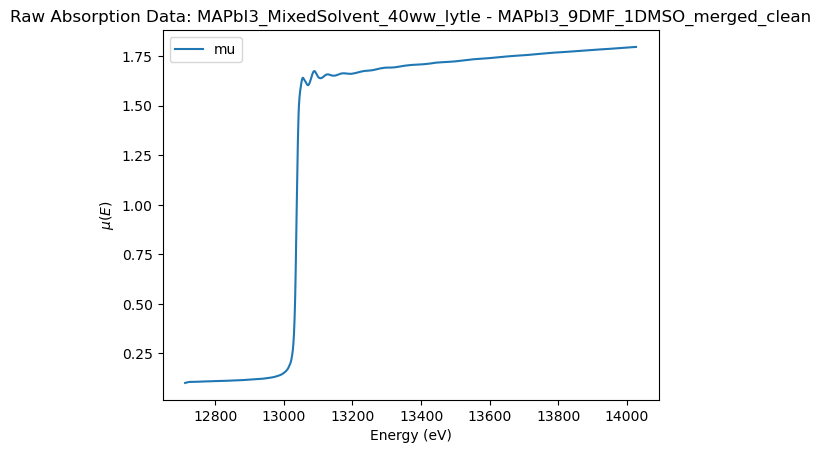


Processing Group: MAPbI3_3DMF_1DMSO_merged_clean
   athena_id -> <class 'str'>
   athena_params -> <class 'larch.symboltable.Group'>
   atsym -> <class 'str'>
   datatype -> <class 'str'>
   edge -> <class 'str'>
   energy -> <class 'numpy.ndarray'>
   epsk -> <class 'str'>
   epsr -> <class 'str'>
   filename -> <class 'str'>
   label -> <class 'str'>
   lasso_yvalue -> <class 'str'>
   mu -> <class 'numpy.ndarray'>
   plot_xlabel -> <class 'str'>
   plot_ylabel -> <class 'str'>
   sel -> <class 'int'>
   signal -> <class 'numpy.ndarray'>
   valence -> <class 'str'>
   xdat -> <class 'numpy.ndarray'>
   ydat -> <class 'numpy.ndarray'>
   yerr -> <class 'float'>


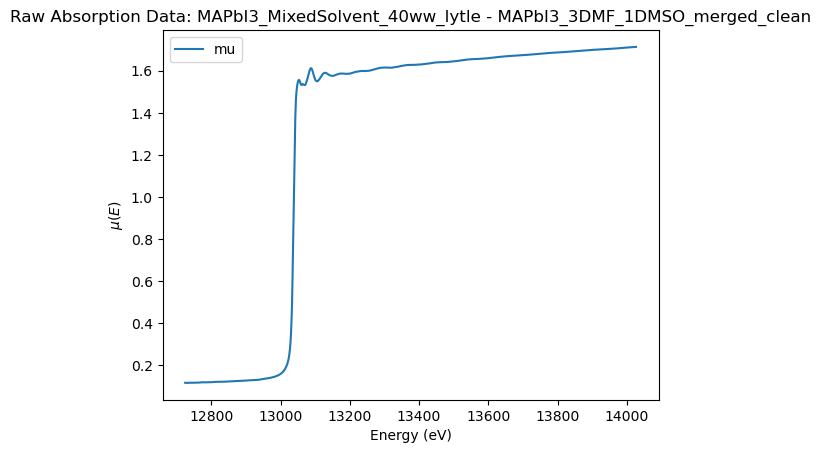


Processing Group: MAPbI3_1DMF_1DMSO_merged_clean
   athena_id -> <class 'str'>
   athena_params -> <class 'larch.symboltable.Group'>
   atsym -> <class 'str'>
   datatype -> <class 'str'>
   edge -> <class 'str'>
   energy -> <class 'numpy.ndarray'>
   epsk -> <class 'str'>
   epsr -> <class 'str'>
   filename -> <class 'str'>
   label -> <class 'str'>
   lasso_yvalue -> <class 'str'>
   mu -> <class 'numpy.ndarray'>
   plot_xlabel -> <class 'str'>
   plot_ylabel -> <class 'str'>
   sel -> <class 'int'>
   signal -> <class 'numpy.ndarray'>
   valence -> <class 'str'>
   xdat -> <class 'numpy.ndarray'>
   ydat -> <class 'numpy.ndarray'>
   yerr -> <class 'float'>


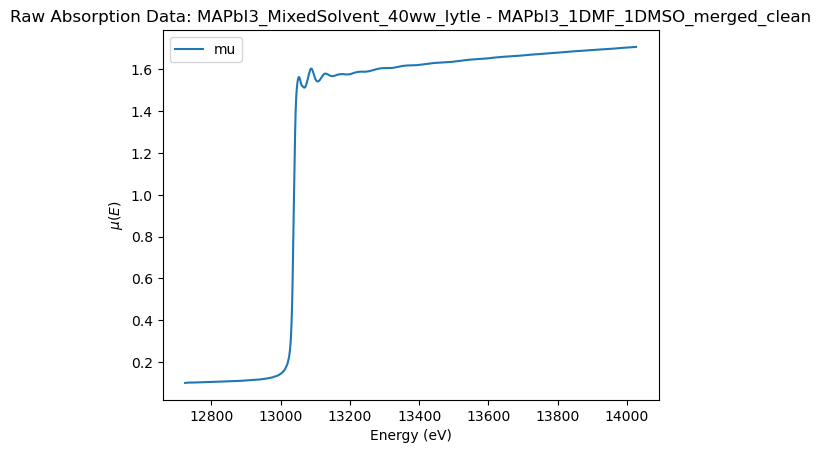

Found 1 Athena project files:
  - MAPbI3_MixedSolvent_40ww_lytle.prj

Loading MAPbI3_MixedSolvent_40ww_lytle.prj...
  Loaded: MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean (469 points)
  Loaded: MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean (469 points)
  Loaded: MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean (467 points)

Total spectra loaded: 3

✅ Successfully loaded 3 spectra:
  - MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean
  - MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean
  - MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean


In [11]:
# Set the path to your folder containing Athena project files
athena_folder_path = r"C:\Users\Keenan Wyatt\OneDrive - UCB-O365\Data\XAS\MixedSolvent\athena"
xas_processor = XASmu2r(athena_folder_path)

# Optional: filter which groups to process (None = all groups)
# Examples: '*merge*' for only merged data, '*sample*' for groups containing 'sample'
match_pattern = None  # Set to None to process all groups

def load_athena_projects(folder_path, match_pattern=None):
    """
    Load all Athena project files from a folder and extract spectra with group information.
    
    Parameters
    ----------
    folder_path : str
        Path to folder containing .prj files
    match_pattern : str or None
        Pattern to filter groups (e.g., '*merge*' for merged data only)
        
    Returns
    -------
    dict
        Dictionary with sample names as keys and (energy, mu, group_data) tuples as values
    """
    if not USE_LARCH:
        raise ImportError("Larch is required to read Athena project files")
    
    folder_path = Path(folder_path)
    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    
    # Find all .prj files in the folder
    prj_files = list(folder_path.glob("*.prj"))
    if not prj_files:
        raise FileNotFoundError(f"No .prj files found in {folder_path}")
    
    print(f"Found {len(prj_files)} Athena project files:")
    for prj_file in prj_files:
        print(f"  - {prj_file.name}")
    
    all_spectra = {}
    all_groups = {}  # Store group data for E0 verification
    
    for prj_file in prj_files:
        print(f"\nLoading {prj_file.name}...")
        try:
            # Read the Athena project file
            project_data = read_athena(prj_file, match=match_pattern, do_preedge=True)
            
            # Extract spectra from each group in the project
            for group_name, group_data in project_data.items():
                if hasattr(group_data, 'energy') and hasattr(group_data, 'mu'):
                    # Create a unique sample name combining project file and group name
                    sample_name = f"{prj_file.stem}_{group_name}"
                    
                    # Get energy and mu arrays
                    energy = np.array(group_data.energy)
                    mu = np.array(group_data.mu)
                    
                    # Sort by energy to ensure proper ordering
                    sort_idx = np.argsort(energy)
                    energy = energy[sort_idx]
                    mu = mu[sort_idx]
                    
                    # Store both spectrum data and group data
                    all_spectra[sample_name] = (energy, mu, group_data)
                    all_groups[sample_name] = group_data
                    print(f"  Loaded: {sample_name} ({len(energy)} points)")
                else:
                    print(f"  Skipped: {group_name} (missing energy/mu data)")
                    
        except Exception as e:
            print(f"  Error loading {prj_file.name}: {e}")
    
    print(f"\nTotal spectra loaded: {len(all_spectra)}")
    return all_spectra, all_groups

# Load all spectra from Athena project files
try:
    all_spectra, all_groups = load_athena_projects(athena_folder_path, match_pattern)
    print(f"\n✅ Successfully loaded {len(all_spectra)} spectra:")
    for name in all_spectra.keys():
        print(f"  - {name}")
except Exception as e:
    print(f"❌ Error loading Athena projects: {e}")
    print("Please check your folder path and ensure it contains .prj files")
    all_spectra = {}
    all_groups = {}


## Step 3: Verify E0 Values

This section verifies the E0 values for each group from every project. E0 is the edge energy and is critical for proper analysis.


=== E0 VERIFICATION RESULTS ===

Sample Name                                                  E0 (eV)    Status          Difference (eV)
----------------------------------------------------------------------------------------------------
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean 13036.5    ✅ Good          0.5            
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean 13036.3    ✅ Good          0.7            
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean 13037.0    ✅ Good          0.0            

=== SUMMARY ===
Total groups: 3
Good E0 values: 3
Acceptable E0 values: 0
Poor/Error E0 values: 0


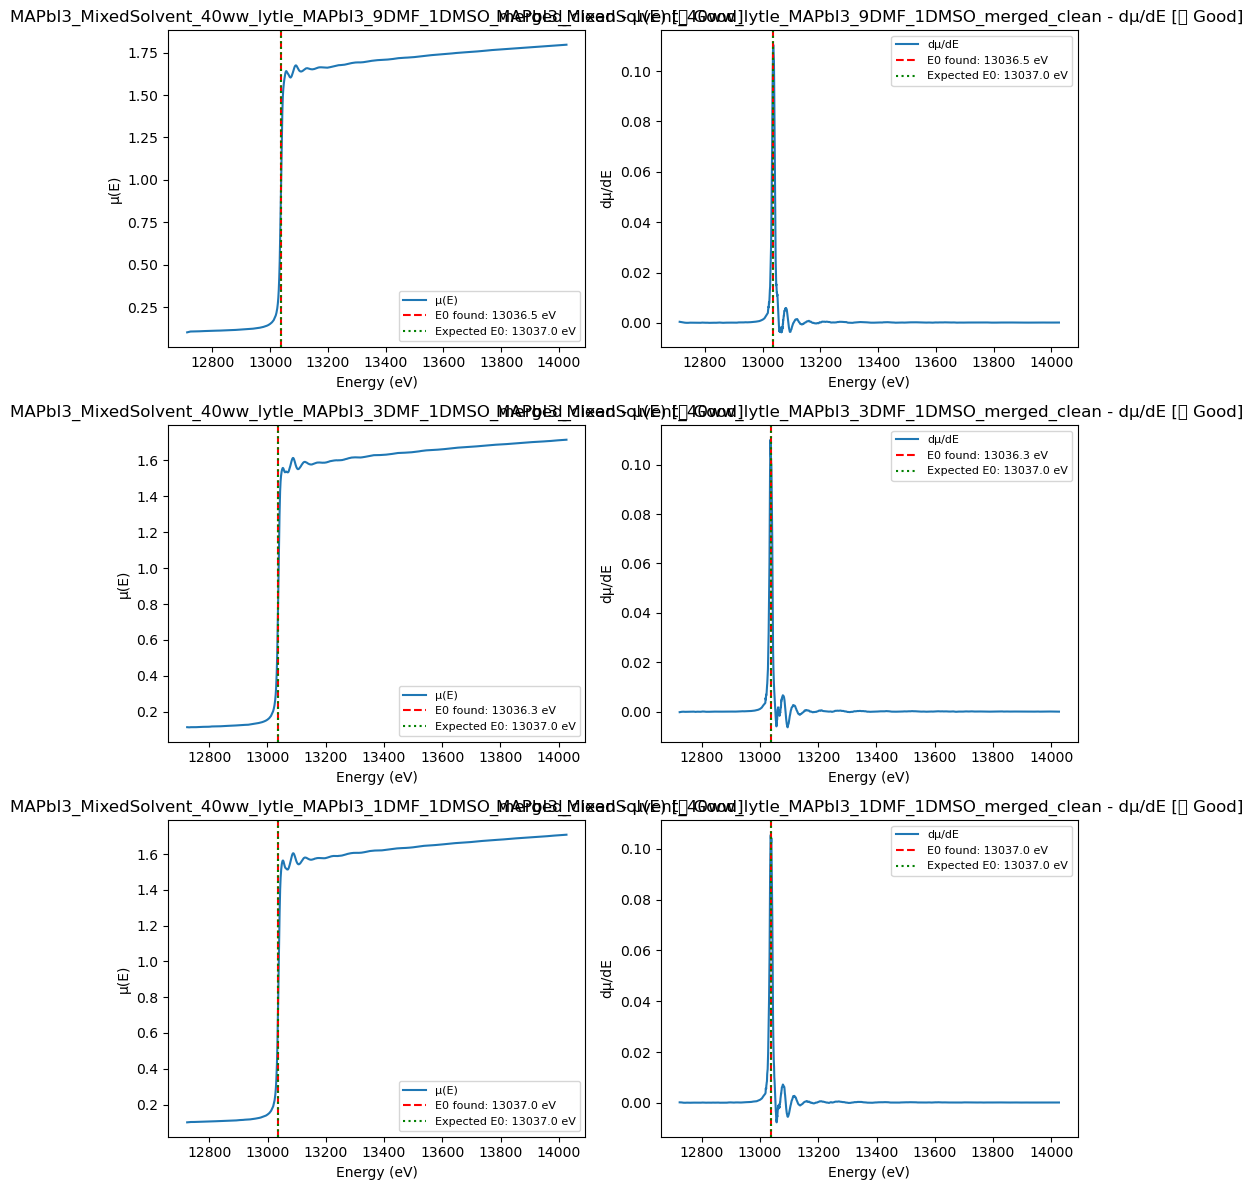

Loading project file: MAPbI3_MixedSolvent_40ww_lytle.prj

Available Groups in Project 'MAPbI3_MixedSolvent_40ww_lytle':
   MAPbI3_9DMF_1DMSO_merged_clean
   MAPbI3_3DMF_1DMSO_merged_clean
   MAPbI3_1DMF_1DMSO_merged_clean

Processing Project: MAPbI3_MixedSolvent_40ww_lytle

Processing Group: MAPbI3_9DMF_1DMSO_merged_clean
   athena_id -> <class 'str'>
   athena_params -> <class 'larch.symboltable.Group'>
   atsym -> <class 'str'>
   datatype -> <class 'str'>
   edge -> <class 'str'>
   energy -> <class 'numpy.ndarray'>
   epsk -> <class 'str'>
   epsr -> <class 'str'>
   filename -> <class 'str'>
   label -> <class 'str'>
   lasso_yvalue -> <class 'str'>
   mu -> <class 'numpy.ndarray'>
   plot_xlabel -> <class 'str'>
   plot_ylabel -> <class 'str'>
   sel -> <class 'int'>
   signal -> <class 'numpy.ndarray'>
   valence -> <class 'str'>
   xdat -> <class 'numpy.ndarray'>
   ydat -> <class 'numpy.ndarray'>
   yerr -> <class 'float'>


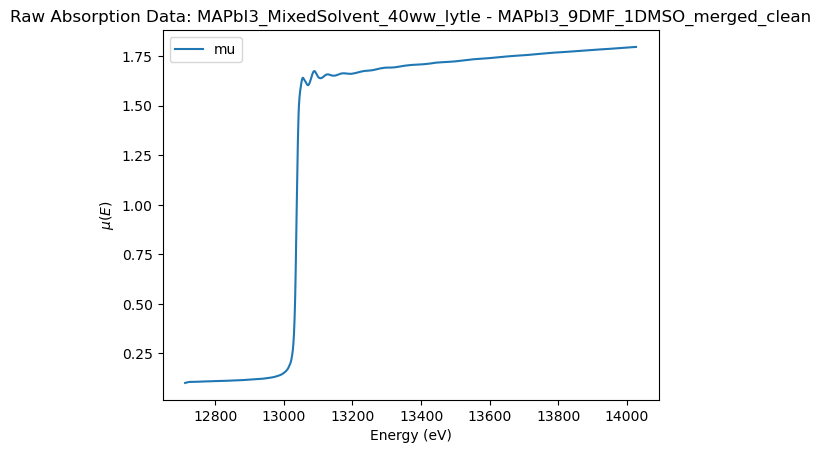


Processing Group: MAPbI3_3DMF_1DMSO_merged_clean
   athena_id -> <class 'str'>
   athena_params -> <class 'larch.symboltable.Group'>
   atsym -> <class 'str'>
   datatype -> <class 'str'>
   edge -> <class 'str'>
   energy -> <class 'numpy.ndarray'>
   epsk -> <class 'str'>
   epsr -> <class 'str'>
   filename -> <class 'str'>
   label -> <class 'str'>
   lasso_yvalue -> <class 'str'>
   mu -> <class 'numpy.ndarray'>
   plot_xlabel -> <class 'str'>
   plot_ylabel -> <class 'str'>
   sel -> <class 'int'>
   signal -> <class 'numpy.ndarray'>
   valence -> <class 'str'>
   xdat -> <class 'numpy.ndarray'>
   ydat -> <class 'numpy.ndarray'>
   yerr -> <class 'float'>


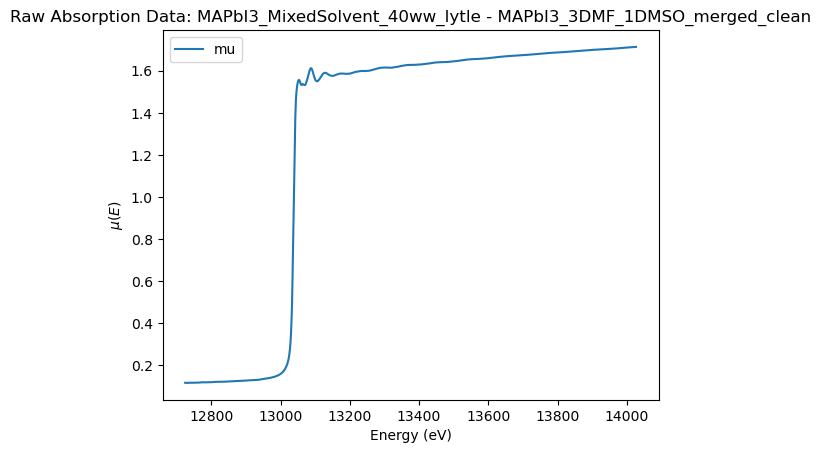


Processing Group: MAPbI3_1DMF_1DMSO_merged_clean
   athena_id -> <class 'str'>
   athena_params -> <class 'larch.symboltable.Group'>
   atsym -> <class 'str'>
   datatype -> <class 'str'>
   edge -> <class 'str'>
   energy -> <class 'numpy.ndarray'>
   epsk -> <class 'str'>
   epsr -> <class 'str'>
   filename -> <class 'str'>
   label -> <class 'str'>
   lasso_yvalue -> <class 'str'>
   mu -> <class 'numpy.ndarray'>
   plot_xlabel -> <class 'str'>
   plot_ylabel -> <class 'str'>
   sel -> <class 'int'>
   signal -> <class 'numpy.ndarray'>
   valence -> <class 'str'>
   xdat -> <class 'numpy.ndarray'>
   ydat -> <class 'numpy.ndarray'>
   yerr -> <class 'float'>


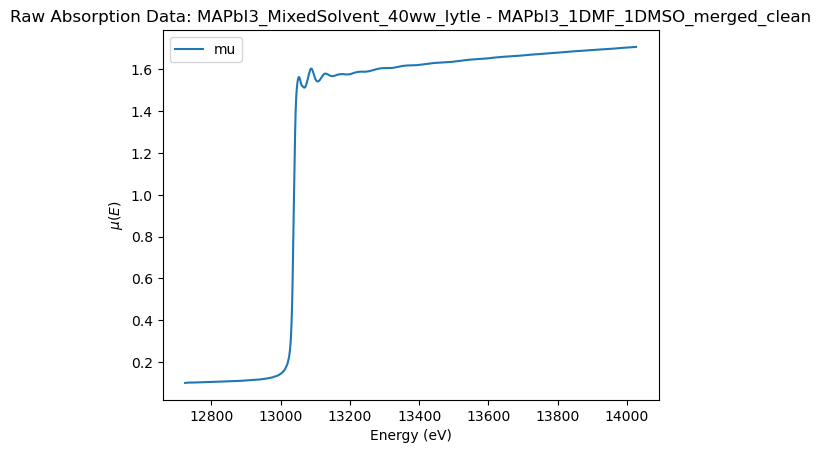


Project: MAPbI3_MixedSolvent_40ww_lytle
Available groups: ['MAPbI3_9DMF_1DMSO_merged_clean', 'MAPbI3_3DMF_1DMSO_merged_clean', 'MAPbI3_1DMF_1DMSO_merged_clean']
MAPbI3_9DMF_1DMSO_merged_clean: e0 = 13036.483, edge_step = 1.4969022718251372
MAPbI3_3DMF_1DMSO_merged_clean: e0 = 13036.259, edge_step = 1.415687154053973
MAPbI3_1DMF_1DMSO_merged_clean: e0 = 13036.96, edge_step = 1.4177242171248077
Number of e0 values found: 3

Global average e0: 13036.57 eV


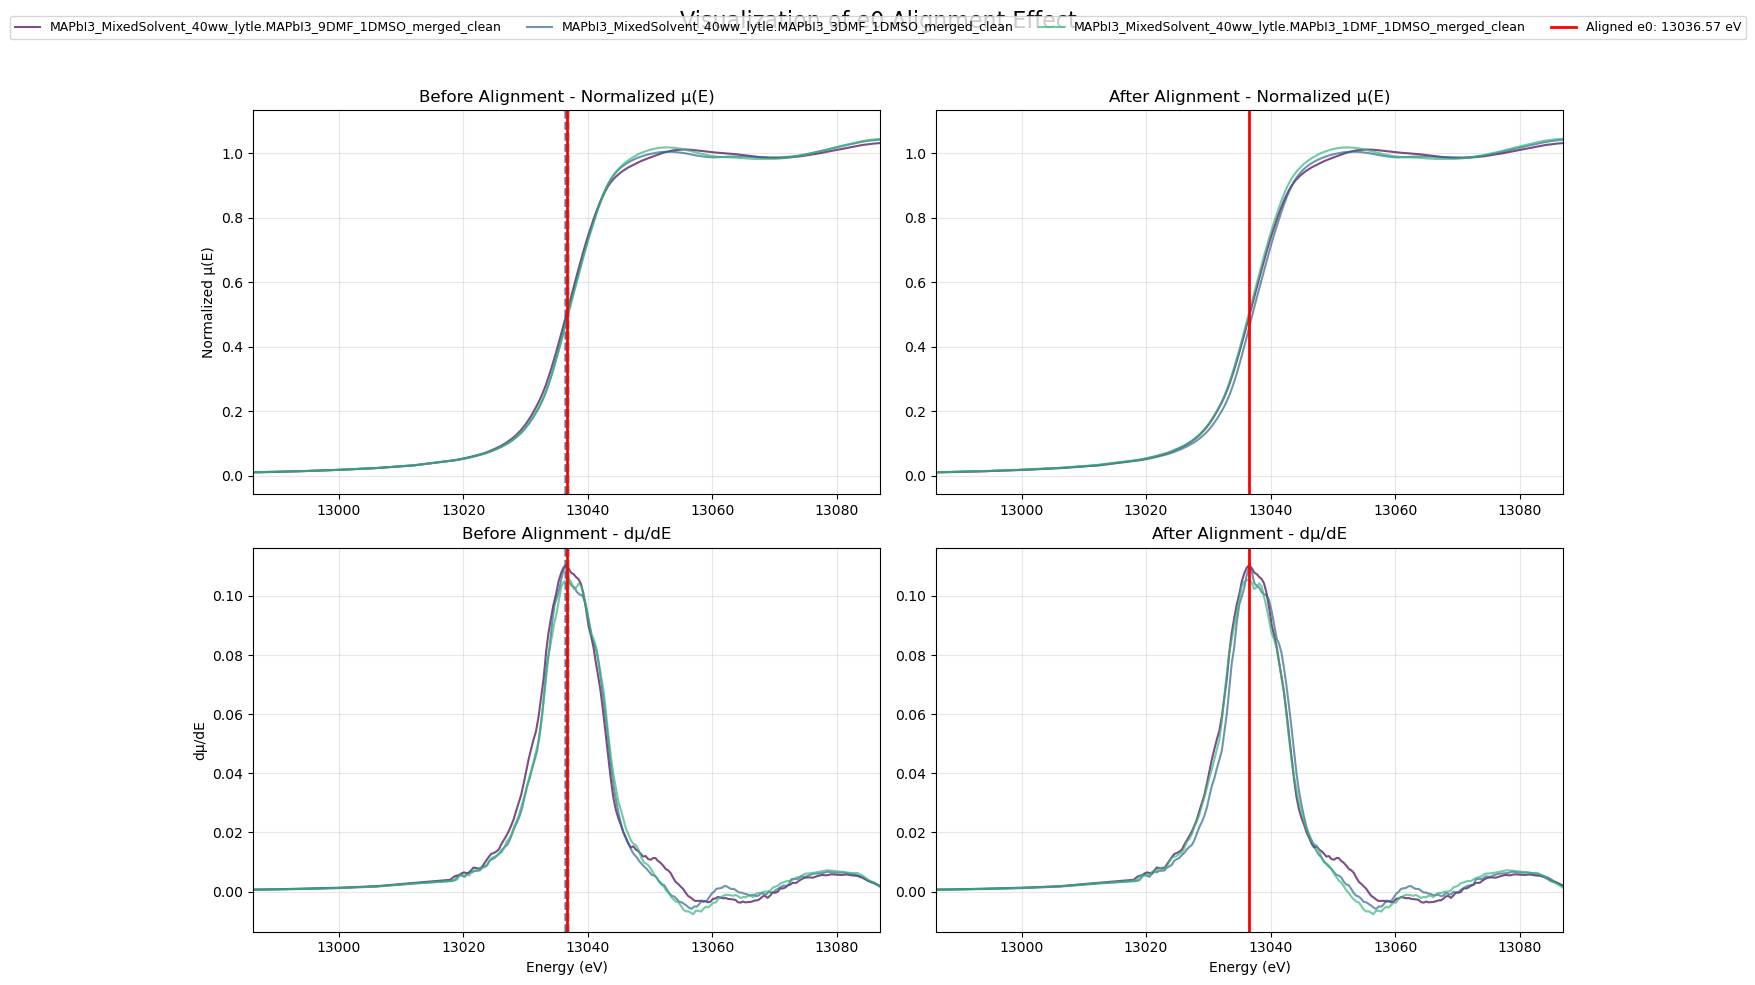

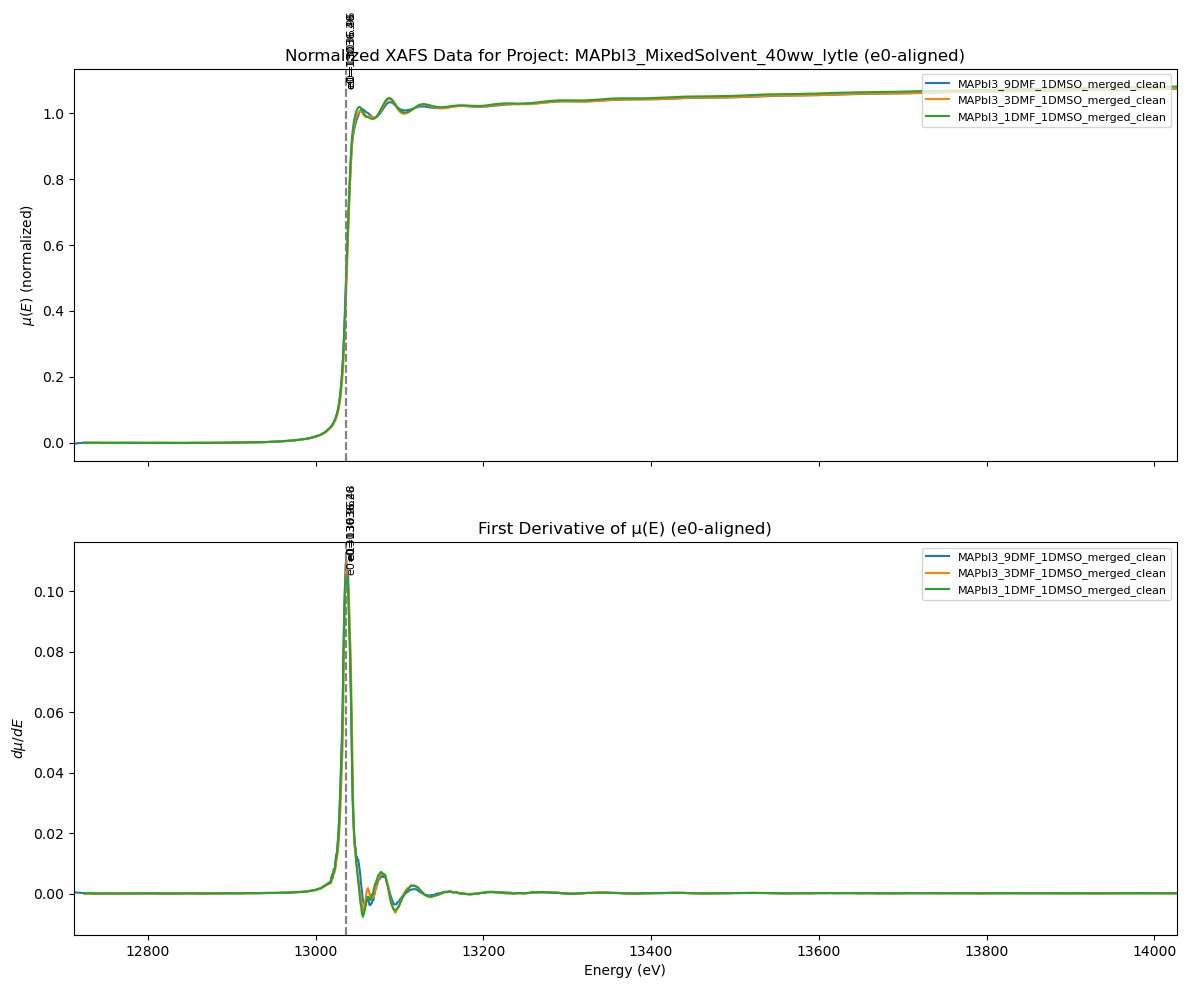

In [12]:
def verify_e0_values(all_groups, expected_e0=13037.0, plot_examples=3):
    """
    Verify E0 values for all groups from every project, and plot E0 on mu(E) and dmu/dE for a few examples.
    
    Parameters
    ----------
    all_groups : dict
        Dictionary of group data from Athena projects
    expected_e0 : float
        Expected E0 value (eV) - default 13037 eV for Pb L3 edge
    plot_examples : int
        Number of example spectra to plot with E0 visualization
        
    Returns
    -------
    dict
        Dictionary with E0 verification results for each group
    """
    import numpy as np
    import matplotlib.pyplot as plt

    e0_results = {}
    plot_data = []

    print("=== E0 VERIFICATION RESULTS ===\n")
    print(f"{'Sample Name':<60} {'E0 (eV)':<10} {'Status':<15} {'Difference (eV)':<15}")
    print("-" * 100)
    
    for sample_name, group_data in all_groups.items():
        try:
            # Get E0 from group data
            if hasattr(group_data, 'e0') and group_data.e0 is not None:
                e0_value = float(group_data.e0)
            else:
                # Calculate E0 from energy and mu if not available
                energy = np.array(group_data.energy)
                mu = np.array(group_data.mu)
                deriv = np.gradient(mu, energy)
                e0_value = energy[np.argmax(deriv)]
            
            # Check if E0 is reasonable
            diff = abs(e0_value - expected_e0)
            if diff < 50:  # Within 50 eV of expected value
                status = "✅ Good"
            elif diff < 100:  # Within 100 eV of expected value
                status = "⚠️ Acceptable"
            else:
                status = "❌ Poor"
            
            e0_results[sample_name] = {
                'e0': e0_value,
                'difference': diff,
                'status': status
            }
            
            print(f"{sample_name:<60} {e0_value:<10.1f} {status:<15} {diff:<15.1f}")

            # Collect data for plotting if we haven't reached the limit
            if len(plot_data) < plot_examples:
                # Always get energy/mu/deriv for plotting
                energy = np.array(group_data.energy)
                mu = np.array(group_data.mu)
                deriv = np.gradient(mu, energy)
                plot_data.append({
                    'sample_name': sample_name,
                    'energy': energy,
                    'mu': mu,
                    'deriv': deriv,
                    'e0': e0_value,
                    'expected_e0': expected_e0,
                    'status': status
                })
            
        except Exception as e:
            e0_results[sample_name] = {
                'e0': None,
                'difference': None,
                'status': f"❌ Error: {str(e)[:20]}"
            }
            print(f"{sample_name:<60} {'N/A':<10} {'❌ Error':<15} {'N/A':<15}")
    
    # Summary statistics
    good_count = sum(1 for r in e0_results.values() if "✅" in r['status'])
    acceptable_count = sum(1 for r in e0_results.values() if "⚠️" in r['status'])
    poor_count = sum(1 for r in e0_results.values() if "❌" in r['status'])
    
    print(f"\n=== SUMMARY ===")
    print(f"Total groups: {len(e0_results)}")
    print(f"Good E0 values: {good_count}")
    print(f"Acceptable E0 values: {acceptable_count}")
    print(f"Poor/Error E0 values: {poor_count}")
    
    if poor_count > 0:
        print(f"\n⚠️ Warning: {poor_count} groups have poor E0 values. Consider energy calibration.")

    # Plot E0 visualization for a few examples
    if len(plot_data) > 0:
        nplots = len(plot_data)
        fig, axes = plt.subplots(nplots, 2, figsize=(10, 4 * nplots), squeeze=False)
        for i, pdata in enumerate(plot_data):
            # mu(E) plot
            ax_mu = axes[i, 0]
            ax_mu.plot(pdata['energy'], pdata['mu'], label='μ(E)')
            ax_mu.axvline(pdata['e0'], color='r', linestyle='--', label=f"E0 found: {pdata['e0']:.1f} eV")
            ax_mu.axvline(pdata['expected_e0'], color='g', linestyle=':', label=f"Expected E0: {pdata['expected_e0']:.1f} eV")
            ax_mu.set_xlabel("Energy (eV)")
            ax_mu.set_ylabel("μ(E)")
            ax_mu.set_title(f"{pdata['sample_name']} - μ(E) [{pdata['status']}]")
            ax_mu.legend(fontsize=8)

            # dmu/dE plot
            ax_deriv = axes[i, 1]
            ax_deriv.plot(pdata['energy'], pdata['deriv'], label="dμ/dE")
            ax_deriv.axvline(pdata['e0'], color='r', linestyle='--', label=f"E0 found: {pdata['e0']:.1f} eV")
            ax_deriv.axvline(pdata['expected_e0'], color='g', linestyle=':', label=f"Expected E0: {pdata['expected_e0']:.1f} eV")
            ax_deriv.set_xlabel("Energy (eV)")
            ax_deriv.set_ylabel("dμ/dE")
            ax_deriv.set_title(f"{pdata['sample_name']} - dμ/dE [{pdata['status']}]")
            ax_deriv.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    
    return e0_results
# Verify E0 values for all loaded groups
if len(all_groups) > 0:
    e0_verification_results = verify_e0_values(all_groups, expected_e0=13037.0)
else:
    print("No groups loaded. Please run the data loading cell first.")
    e0_verification_results = {}
xas_processor.process_athena_projects()
xas_processor.batch_process_projects()




## Step 4: Initialize XASmu2r and Self-Absorption Correction

This section initializes the XASmu2r processor and applies self-absorption correction to all groups. This must be done before background optimization since the background_optimizer() expects the 'norm_corrected' attribute.


Applying self-absorption correction to all groups...
  Processing 'MAPbI3_MixedSolvent_40ww_lytle/MAPbI3_9DMF_1DMSO_merged_clean'...
  ✓ Applied correction (thickness=1000 μm, incident=45.0°, emission=45.0°)
  Processing 'MAPbI3_MixedSolvent_40ww_lytle/MAPbI3_3DMF_1DMSO_merged_clean'...
  ✓ Applied correction (thickness=1000 μm, incident=45.0°, emission=45.0°)
  Processing 'MAPbI3_MixedSolvent_40ww_lytle/MAPbI3_1DMF_1DMSO_merged_clean'...
  ✓ Applied correction (thickness=1000 μm, incident=45.0°, emission=45.0°)

Self-absorption correction summary:
  Processed 3 groups
  Skipped 0 groups


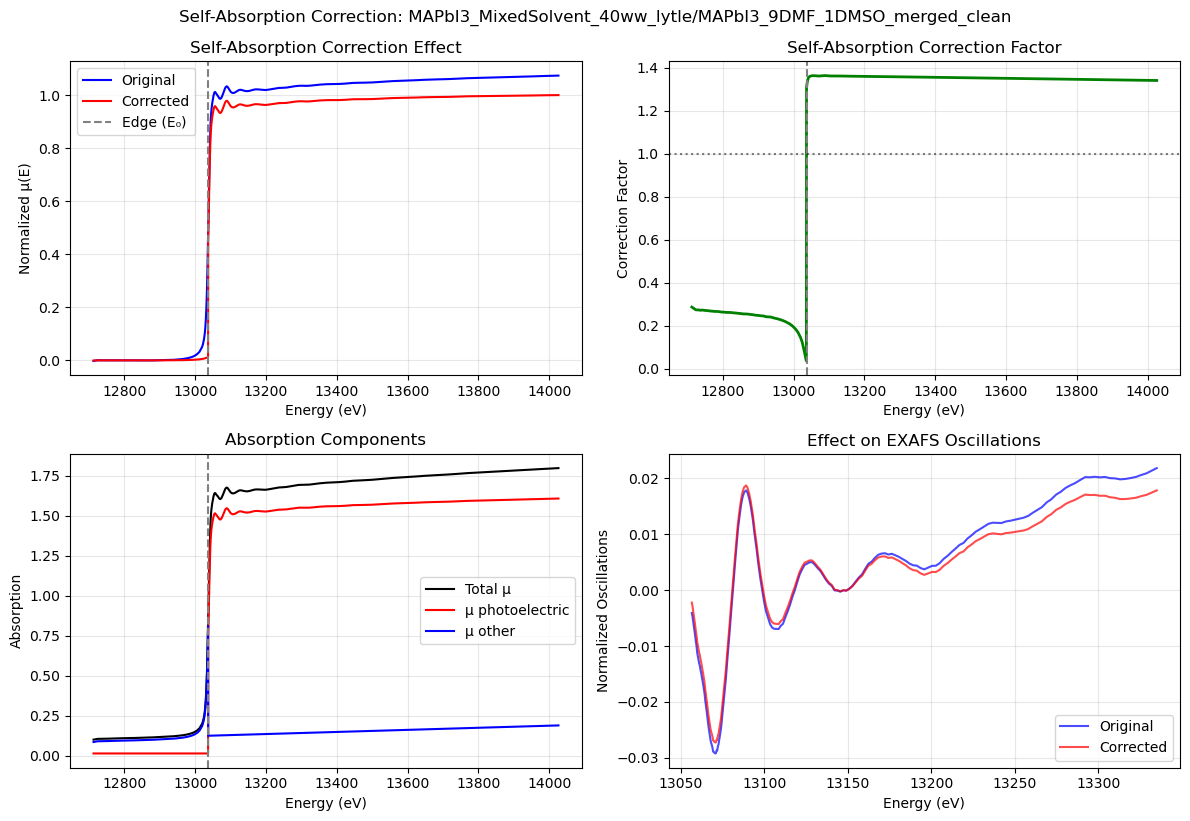

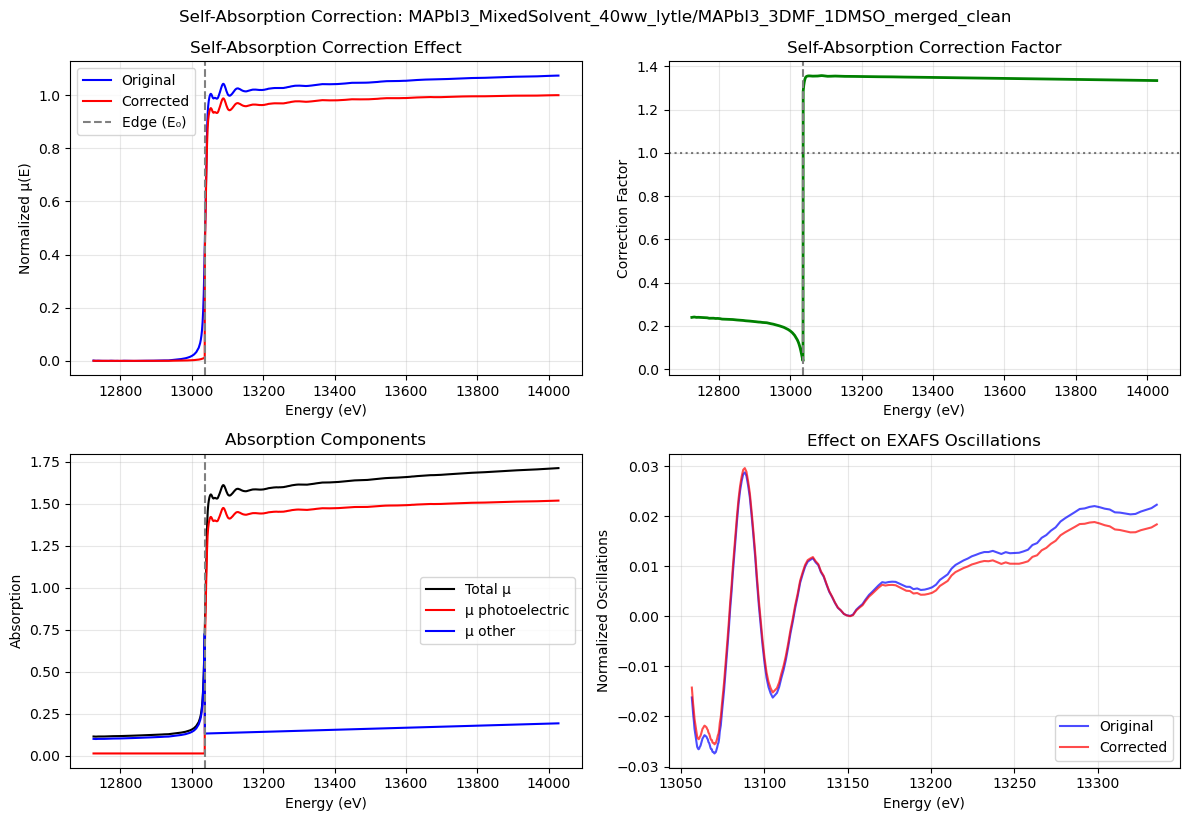

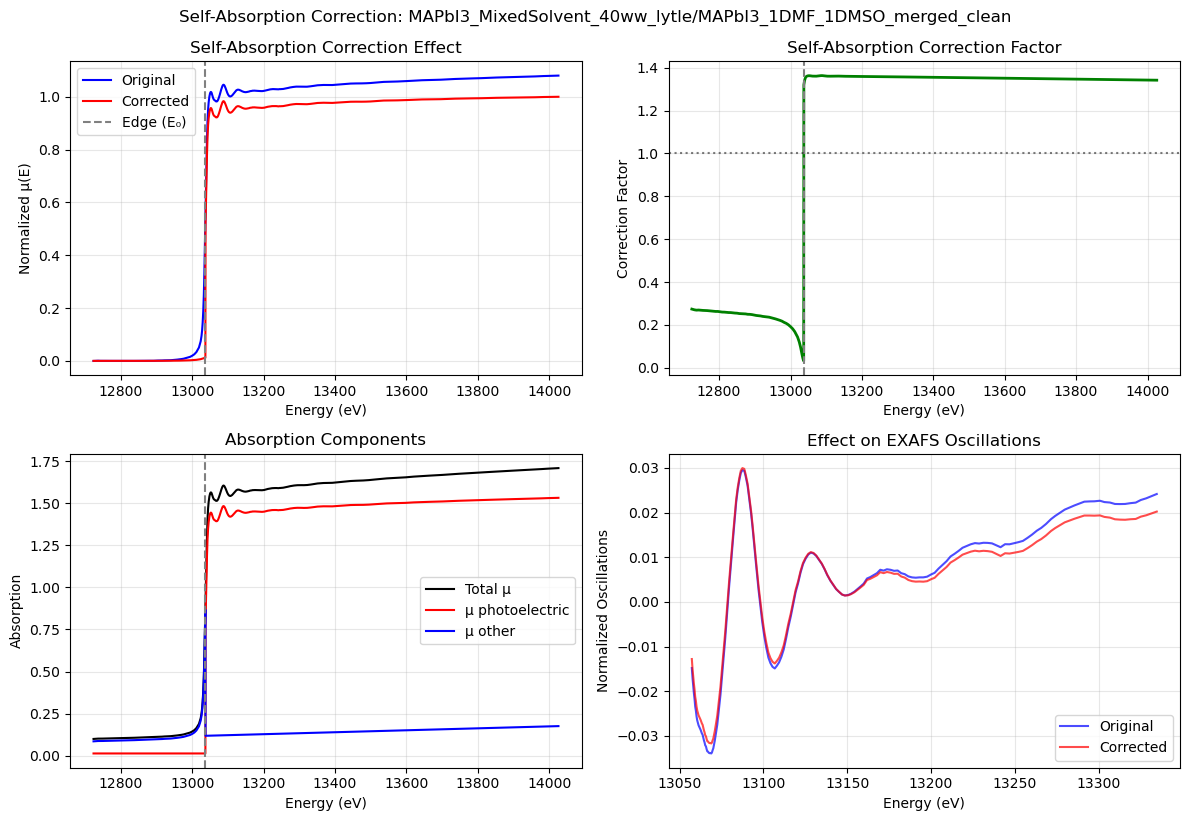

In [13]:
# # Updated function with process_athena_projects() call
# def initialize_xasmu2r_processor_updated(athena_folder_path):
#     """
#     Initialize XASmu2r processor with Athena project files and process them.
    
#     Parameters
#     ----------
#     athena_folder_path : str
#         Path to folder containing Athena project files
        
#     Returns
#     -------
#     XASmu2r
#         XASmu2r instance with loaded and processed projects
#     """
#     print("=== INITIALIZING XASMU2R PROCESSOR ===\n")
    
#     try:
#         # Initialize XASmu2r with the Athena project folder
#         xas_processor = XASmu2r(athena_folder_path)
        
#         print(f"✅ Successfully initialized XASmu2r processor")
#         print(f"✅ Loaded {len(xas_processor.projects)} projects")
        
#         # Count total groups
#         total_groups = sum(len(project.groups) for project in xas_processor.projects.values())
#         print(f"✅ Total groups loaded: {total_groups}")
        
#         # Explicitly call process_athena_projects to ensure proper processing
#         print(f"\n=== PROCESSING ATHENA PROJECTS ===\n")
#         xas_processor.process_athena_projects()
        
#         print(f"\n✅ Successfully processed all Athena projects")
        
#         return xas_processor
        
#     except Exception as e:
#         print(f"❌ Error initializing XASmu2r processor: {e}")
#         return None

# # Use the updated function instead
# if len(all_groups) > 0:
#     xas_processor = initialize_xasmu2r_processor_updated(athena_folder_path)
    
#     # Apply self-absorption correction using XASmu2r
#     if xas_processor is not None:
#         xas_processor = apply_self_absorption_correction_xasmu2r(
#             xas_processor, thickness=0.01, incident_angle=45.0, emission_angle=45.0)
#     else:
#         print("Failed to initialize XASmu2r processor.")
# else:
#     print("No groups loaded. Please run the data loading cell first.")
#     xas_processor = None

xas_processor.apply_self_absorption_correction_all()


## Step 5: Background Optimization

This section uses the background_optimizer() method to find appropriate r background values for each group. This is now performed after self-absorption correction since the background_optimizer() expects the 'norm_corrected' attribute.



Processing Project: MAPbI3_MixedSolvent_40ww_lytle
  Group MAPbI3_9DMF_1DMSO_merged_clean: Optimal rbkg = 1.18


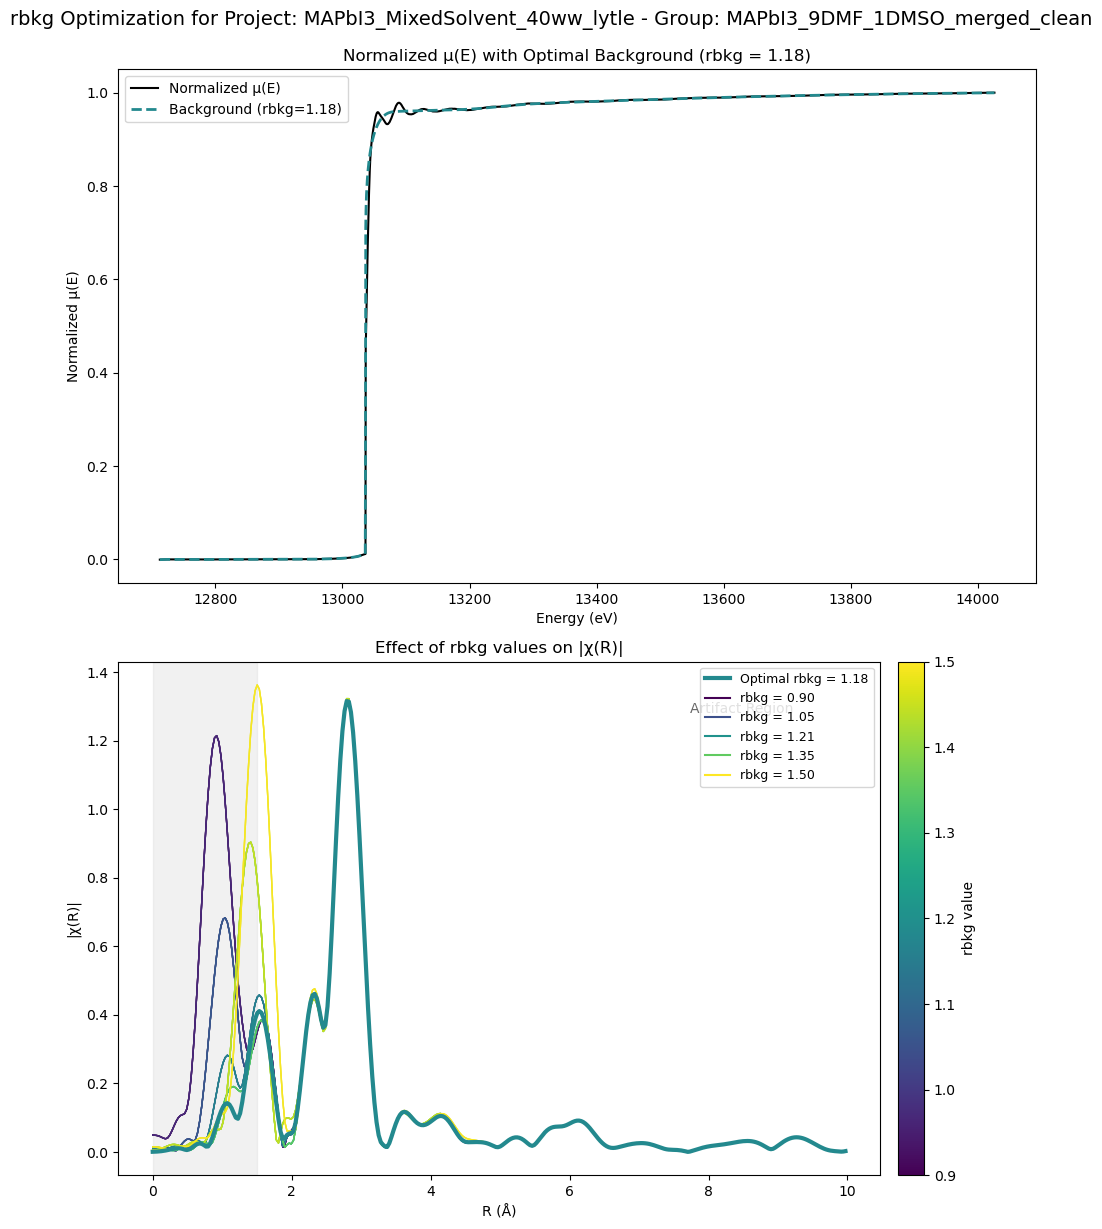

  Group MAPbI3_3DMF_1DMSO_merged_clean: Optimal rbkg = 1.27


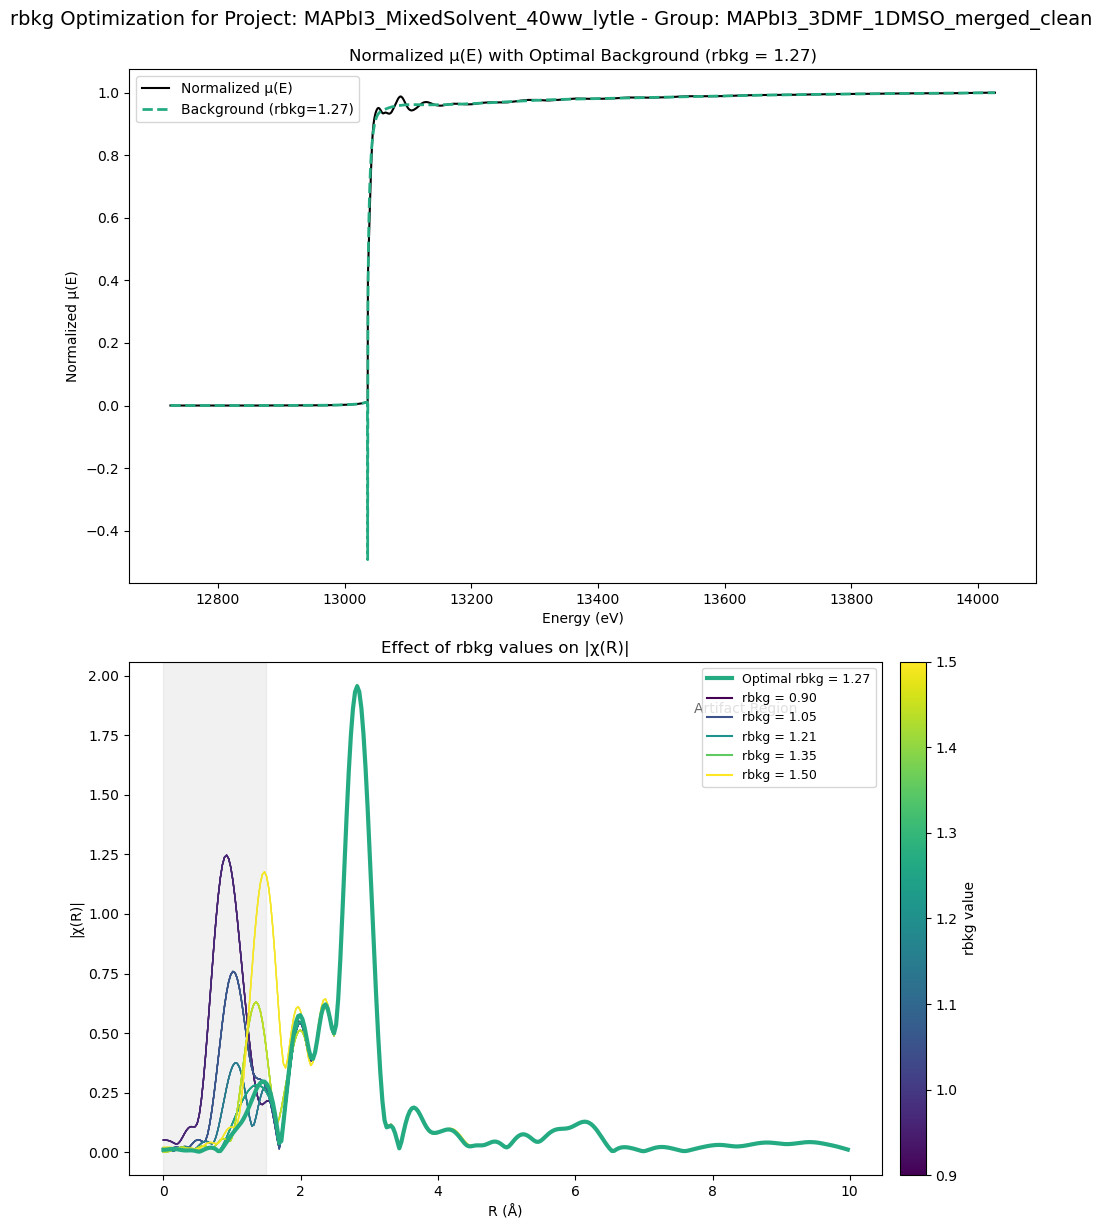

  Group MAPbI3_1DMF_1DMSO_merged_clean: Optimal rbkg = 1.28


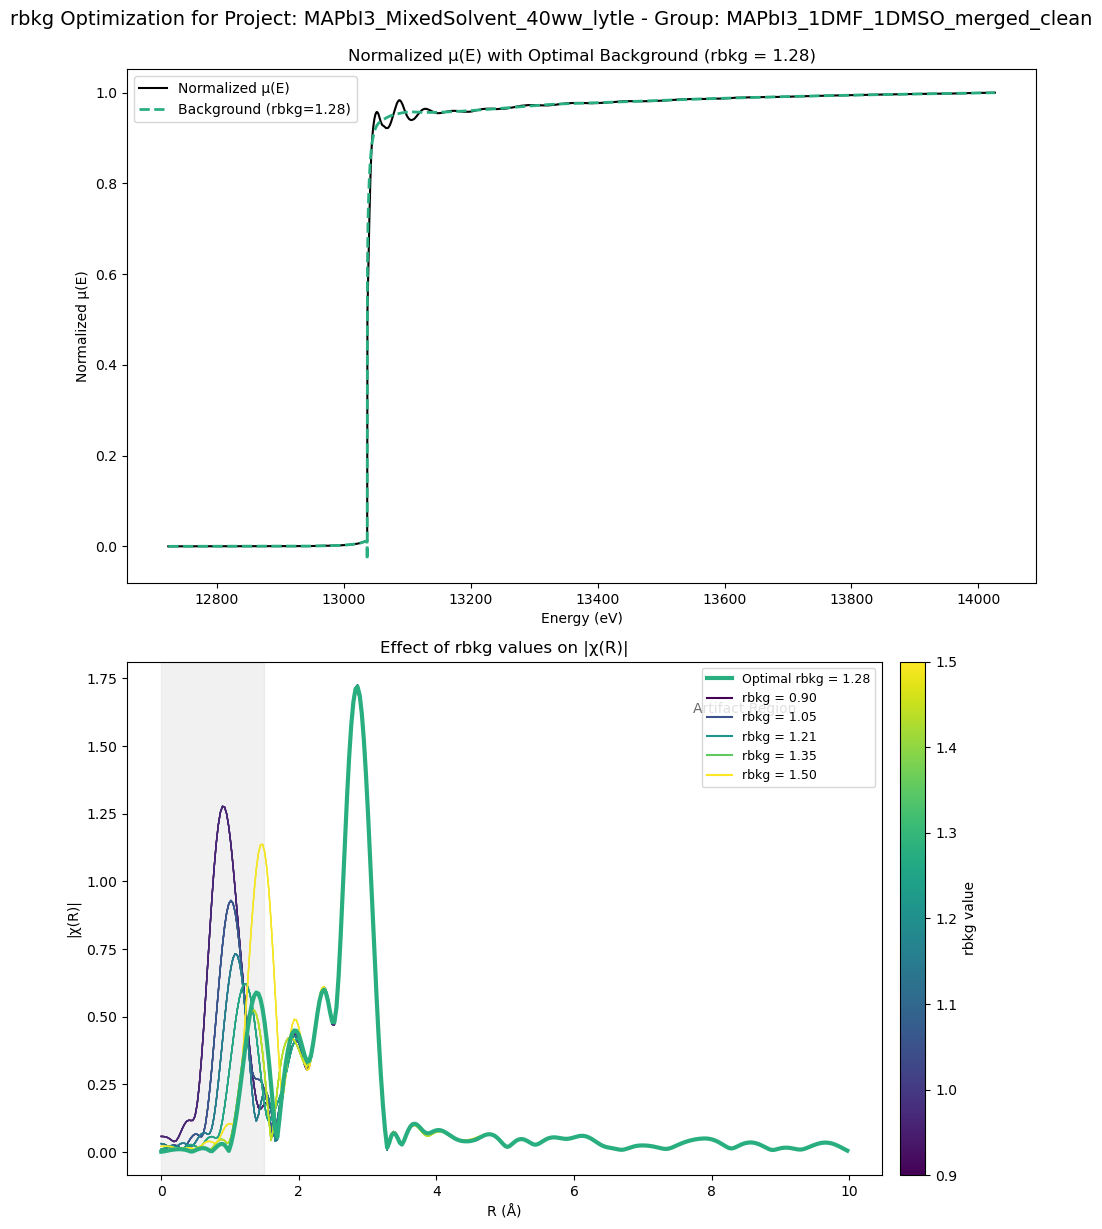


Processing FT for Project 'MAPbI3_MixedSolvent_40ww_lytle', Group 'MAPbI3_9DMF_1DMSO_merged_clean'
  Using data source: chi
  Using rbkg = 1.18 Å

  Analyzing with k-weight 3:
  Found 26 zero crossings
  All zero crossings: [ 0.    1.5   2.6   3.4   4.    4.65  5.1   5.65  6.25  6.85  7.4   7.85
  8.35  8.95  9.55 10.15 10.65 11.25 12.   12.45 12.95 13.65 14.25 14.7
 15.05 15.7 ]
  Selected kmin candidates: [2.6 3.4 4. ]
  Selected kmax candidates: [11.25 12.   12.45 12.95 13.65 14.25]


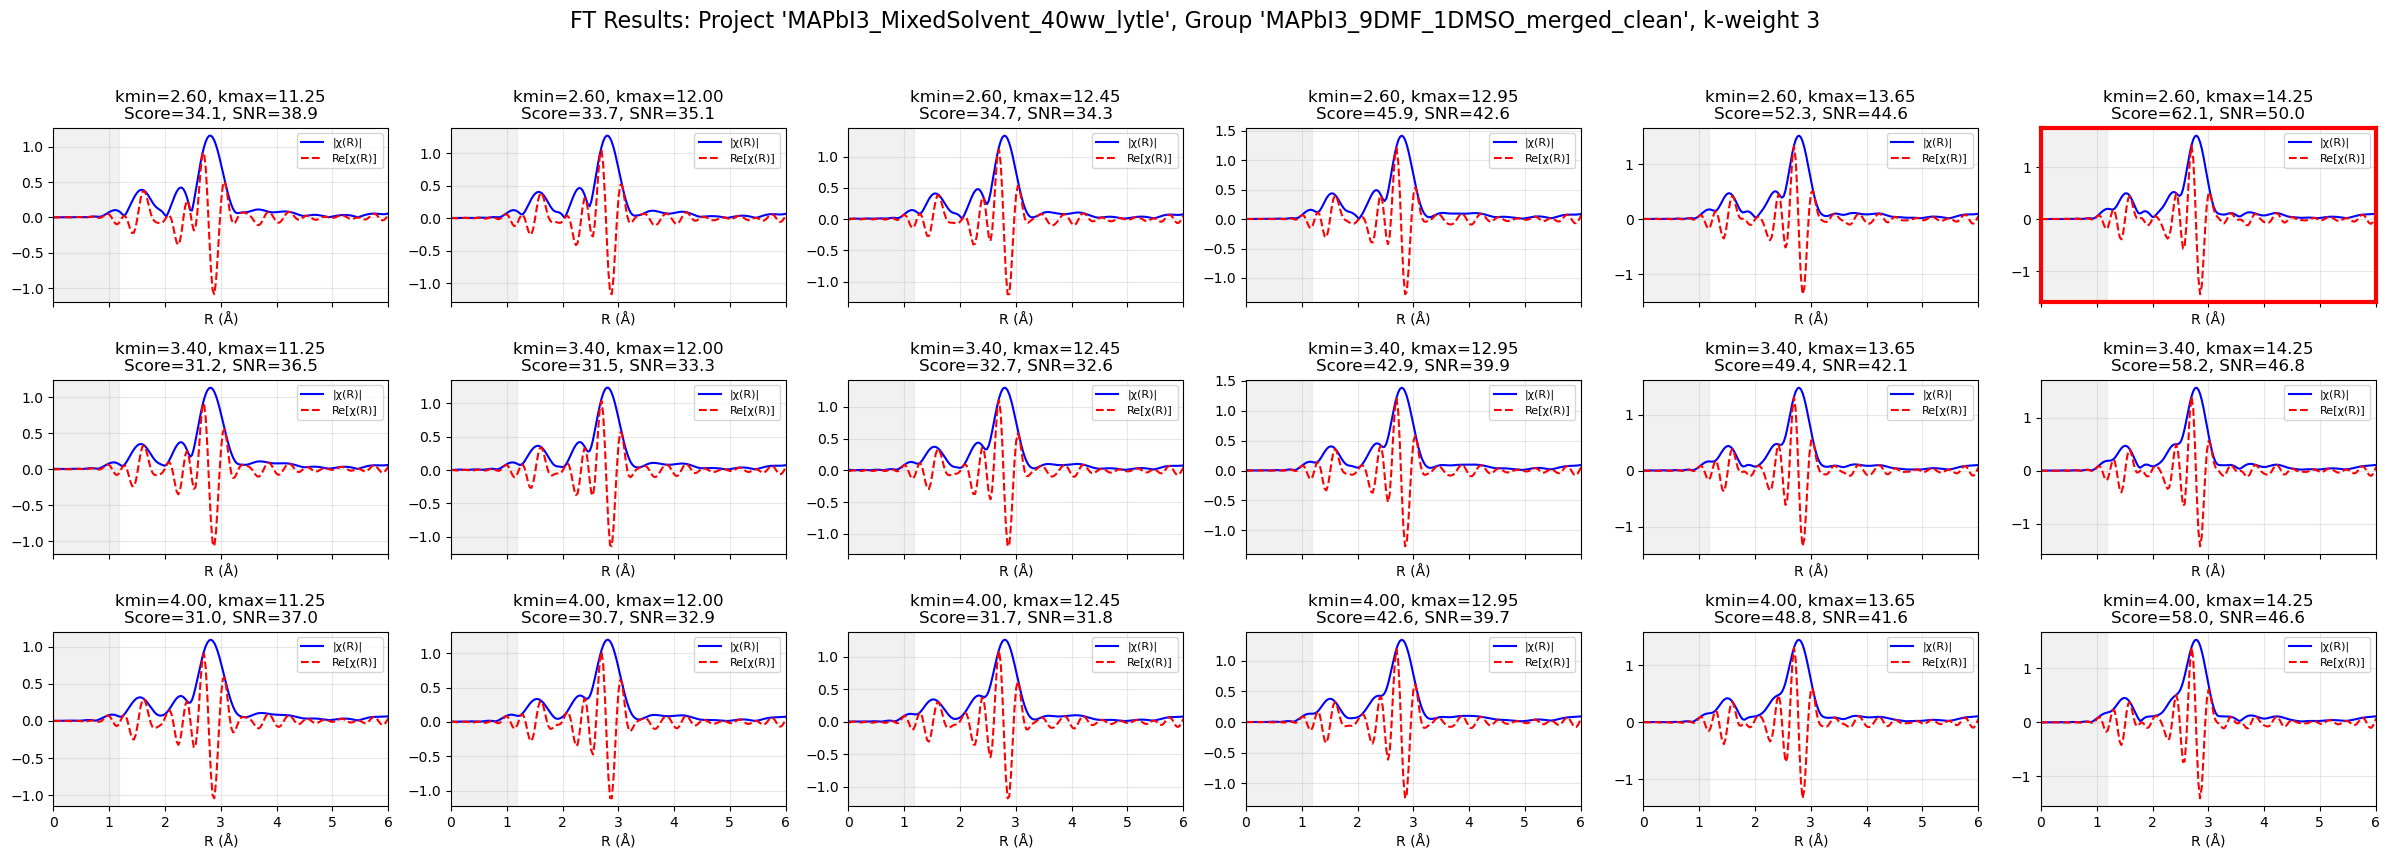

  Best parameters (k-weight 3):
    kmin = 2.600
    kmax = 14.250
    SNR = 50.0
    Quality Score = 62.098467232371256


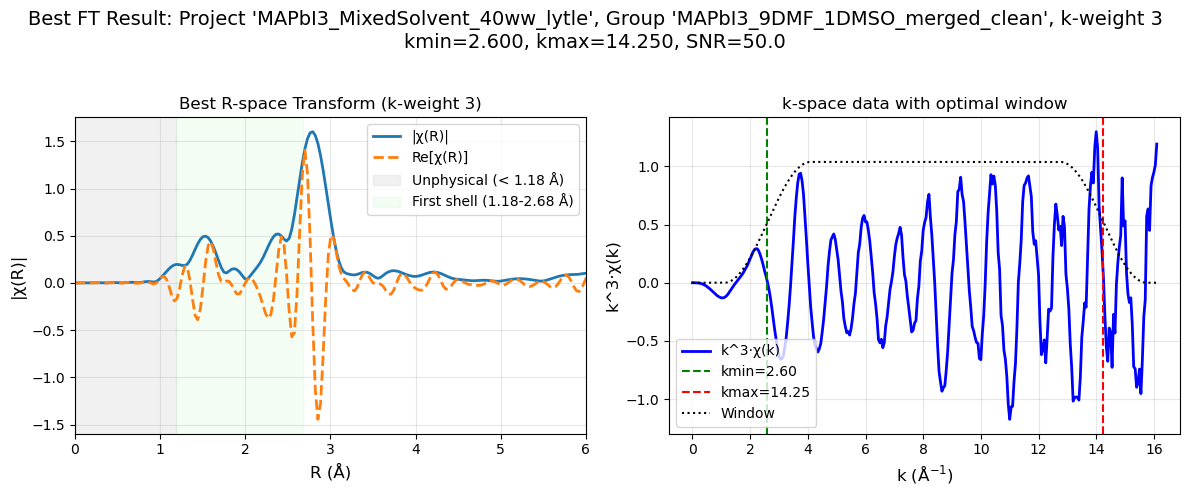


Processing FT for Project 'MAPbI3_MixedSolvent_40ww_lytle', Group 'MAPbI3_3DMF_1DMSO_merged_clean'
  Using data source: chi
  Using rbkg = 1.27 Å

  Analyzing with k-weight 3:
  Found 31 zero crossings
  All zero crossings: [ 0.    0.45  1.35  2.35  3.3   3.95  4.65  5.25  5.75  6.2   6.75  7.3
  7.8   8.4   9.    9.55 10.15 10.65 11.25 11.8  12.3  12.35 12.4  12.9
 13.45 14.05 14.45 14.5  14.55 15.25 15.8 ]
  Selected kmin candidates: [3.3  3.95]
  Selected kmax candidates: [11.25 11.8  12.3  12.35 12.4  12.9 ]


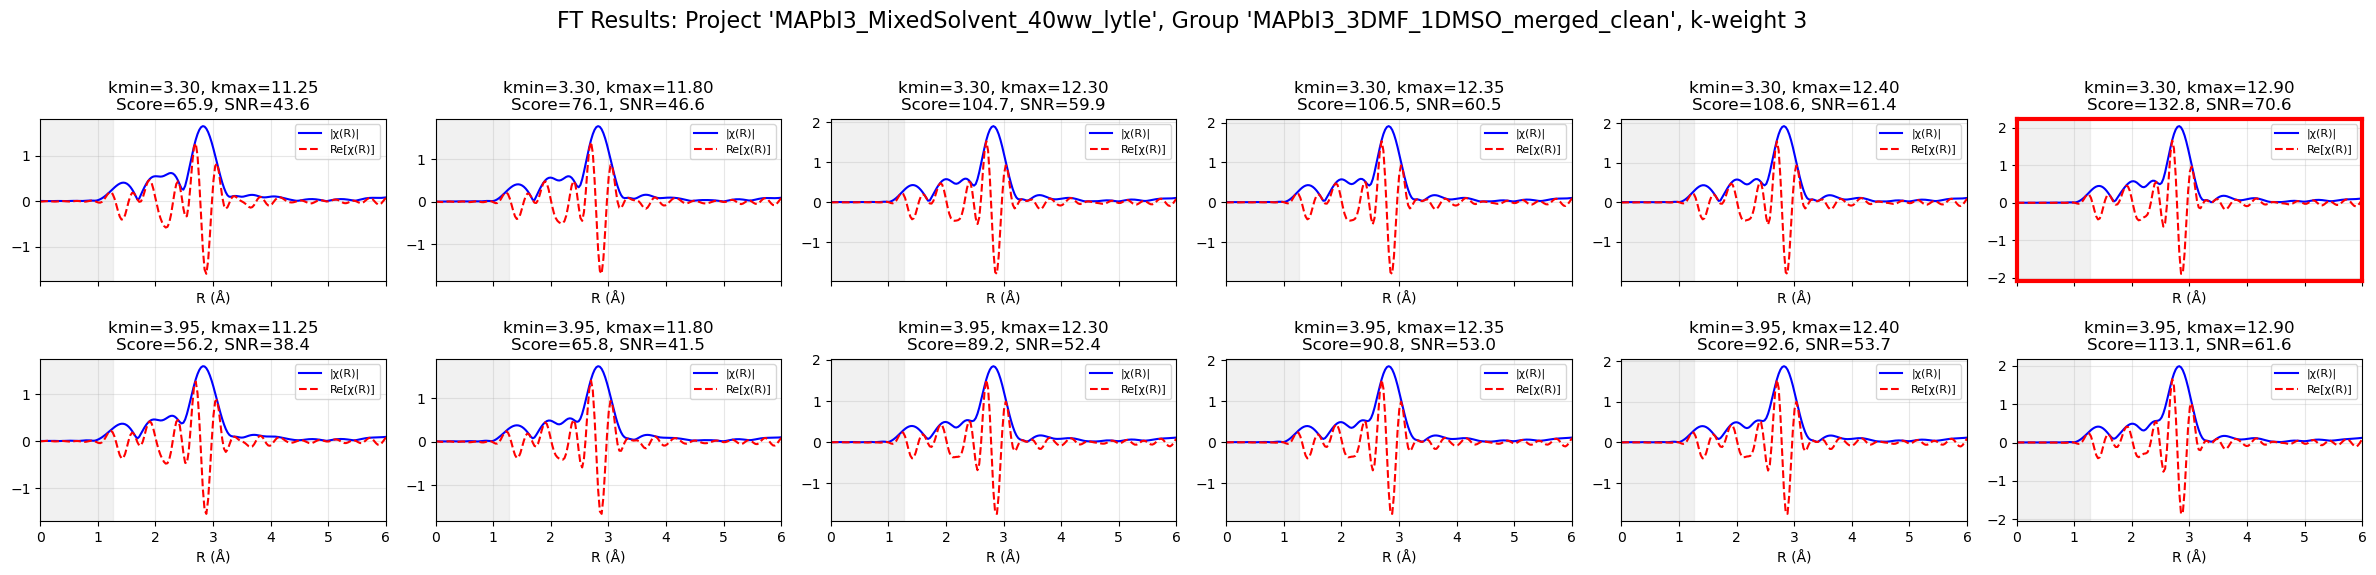

  Best parameters (k-weight 3):
    kmin = 3.300
    kmax = 12.900
    SNR = 70.6
    Quality Score = 132.8470521995621


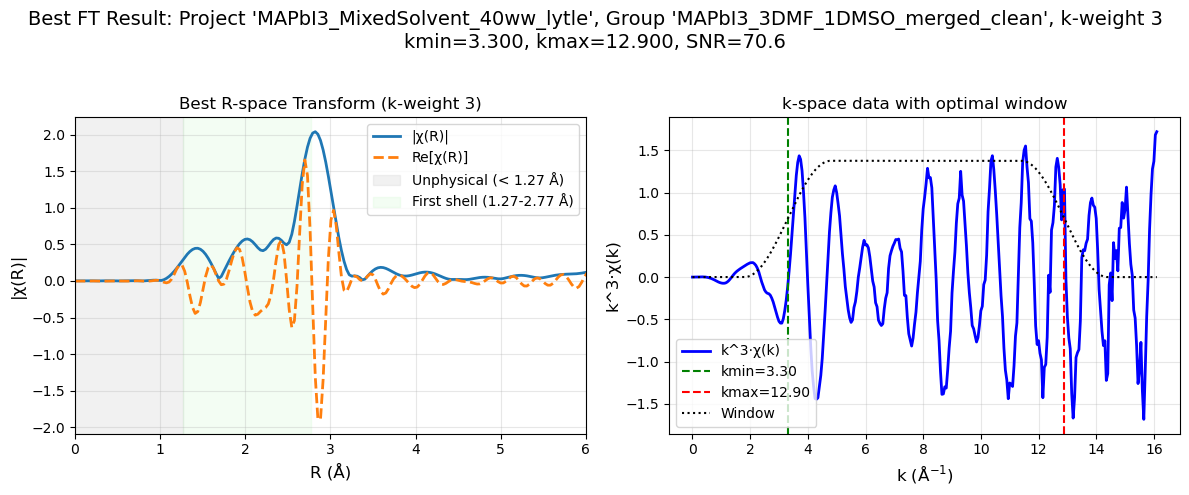


Processing FT for Project 'MAPbI3_MixedSolvent_40ww_lytle', Group 'MAPbI3_1DMF_1DMSO_merged_clean'
  Using data source: chi
  Using rbkg = 1.28 Å

  Analyzing with k-weight 3:
  Found 29 zero crossings
  All zero crossings: [ 0.    0.05  1.35  2.35  3.25  3.95  4.65  5.25  5.65  6.15  6.7   7.25
  7.75  8.35  8.95  9.45 10.   10.6  11.25 11.7  12.25 12.8  13.45 14.
 14.35 15.   15.1  15.2  15.7 ]
  Selected kmin candidates: [3.25 3.95]
  Selected kmax candidates: [11.25 11.7  12.25 12.8  13.45 14.  ]


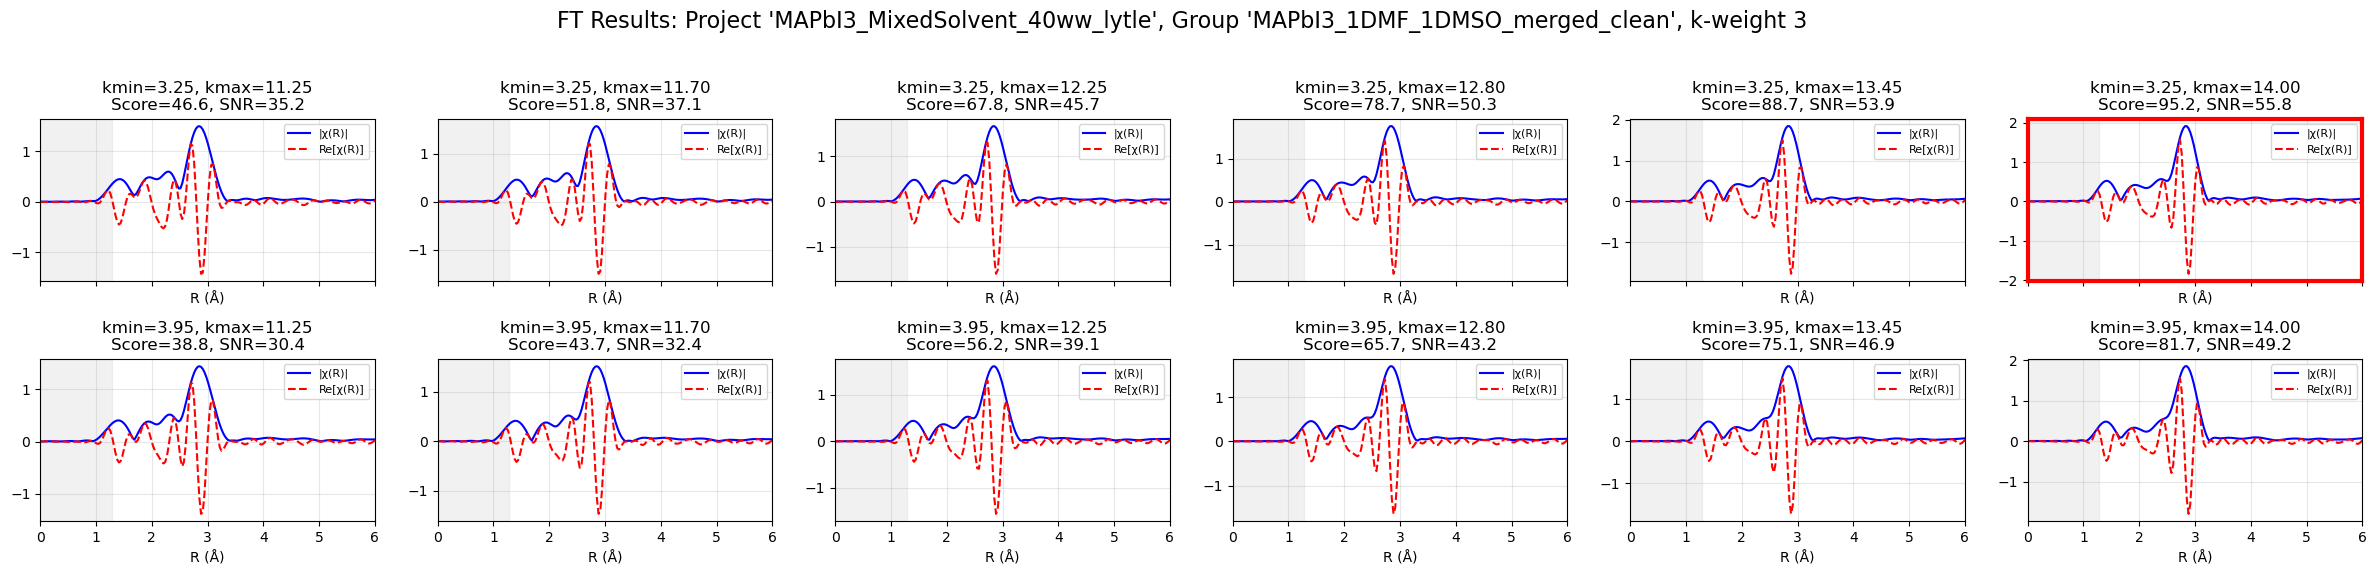

  Best parameters (k-weight 3):
    kmin = 3.250
    kmax = 14.000
    SNR = 55.8
    Quality Score = 95.21096362243908


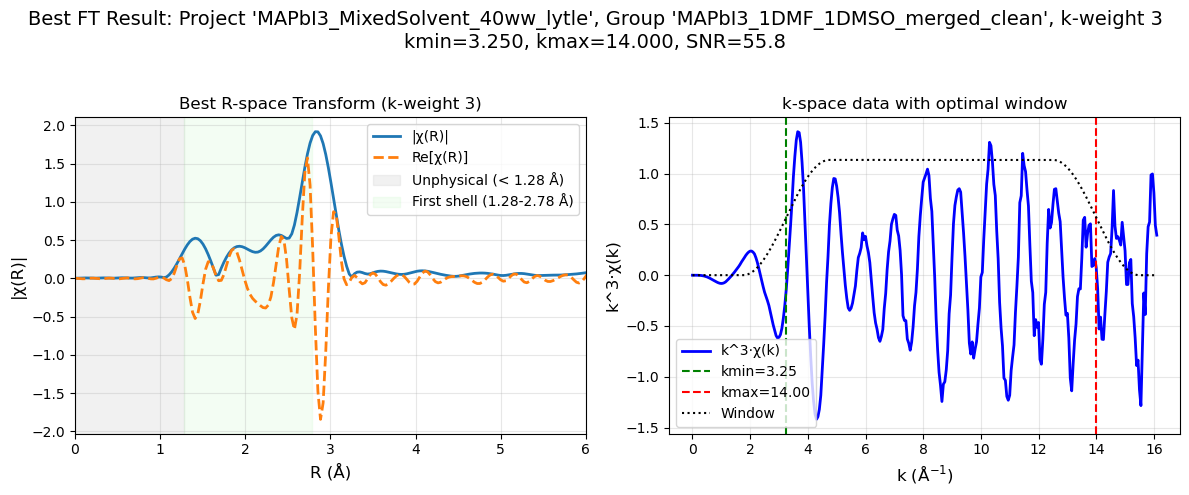

=== Fourier Transform Parameters Used ===
  k-range: 2 to 12 Å⁻¹
  r-range: 0 to 6 Å
  k-weight: 2
  window: hanning



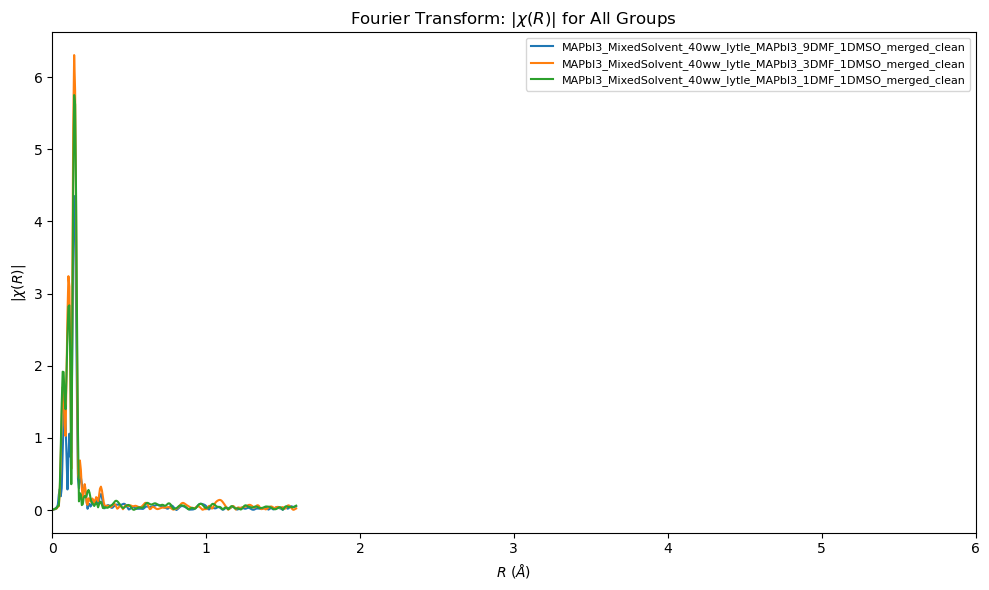

In [ ]:
# def run_background_optimization_xasmu2r(xas_processor):
#     """
#     Run background optimization using XASmu2r class methods.
    
#     Parameters
#     ----------
#     xas_processor : XASmu2r
#         XASmu2r instance with self-absorption correction applied
        
#     Returns
#     -------
#     XASmu2r
#         XASmu2r instance with optimized background parameters
#     """
#     print("=== BACKGROUND OPTIMIZATION USING XASMU2R ===\n")
    
#     if xas_processor is None:
#         print("❌ No XASmu2r processor available. Please run self-absorption correction first.")
#         return None
    
#     try:
#         # Run background optimization
#         xas_processor.background_optimizer()
        
#         print(f"\n✅ Successfully completed background optimization for all groups")
#         return xas_processor
        
#     except Exception as e:
#         print(f"❌ Error during background optimization: {e}")
#         return xas_processor

# # Run background optimization using XASmu2r
# if xas_processor is not None:
#     xas_processor = run_background_optimization_xasmu2r(xas_processor)
# else:
#     print("No XASmu2r processor available. Please run self-absorption correction first.")
xas_processor.background_optimizer()
xas_processor.ft_processing_batch()
from examples.Jupyter.EXAFS_Batch_reduction import kmax, kmin
import numpy as np
import matplotlib.pyplot as plt

# After background optimization, generate a chi(R) plot for all groups in the same plot
def plot_chi_R_all_groups(xas_processor, k_range=(kmin, kmax), r_range=(0, 8), kweight=3, window='hanning'):
    """
    Plot chi(R) for all groups in the same plot and print FT parameters.

    Parameters
    ----------
    xas_processor : XASmu2r
        XASmu2r instance with processed data
    k_range : tuple
        k-range for FT (min, max)
    r_range : tuple
        r-range for plotting (min, max)
    kweight : int
        k-weight for FT
    window : str
        Window function for FT
    """
    if xas_processor is None:
        print("No XASmu2r processor available. Please run previous cells first.")
        return

    # Print FT parameters
    print("=== Fourier Transform Parameters Used ===")
    print(f"  k-range: {k_range[0]} to {k_range[1]} Å⁻¹")
    print(f"  r-range: {r_range[0]} to {r_range[1]} Å")
    print(f"  k-weight: {kweight}")
    print(f"  window: {window}\n")

    # Collect all groups from all projects
    all_groups = []
    for proj_name, project in xas_processor.projects.items():
        for group_name, group in project.groups.items():
            if hasattr(group, 'k') and hasattr(group, 'chi'):
                all_groups.append((f"{proj_name}_{group_name}", group))

    if len(all_groups) == 0:
        print("No groups with chi(k) data found.")
        return

    plt.figure(figsize=(10, 6))
    for label, group in all_groups:
        k = group.k
        chi = group.chi

        # Restrict to k-range
        k_mask = (k >= k_range[0]) & (k <= k_range[1])
        k_ft = k[k_mask]
        chi_ft = chi[k_mask]

        # Apply k-weight
        chi_kw = chi_ft * (k_ft ** kweight)

        # Apply window
        if window == 'hanning':
            win = np.hanning(len(k_ft))
        elif window == 'kaiser':
            win = np.kaiser(len(k_ft), beta=6)
        elif window == 'parzen':
            # Parzen window is not in numpy, use a simple triangular window as approximation
            win = 1 - np.abs(np.linspace(-1, 1, len(k_ft)))
        else:
            win = np.ones(len(k_ft))
        chi_win = chi_kw * win

        # Zero pad to next power of 2 for better FT resolution
        nfft = 2 ** int(np.ceil(np.log2(len(chi_win)) + 1))
        d_k = k_ft[1] - k_ft[0]
        chi_ft_complex = np.fft.fft(chi_win, n=nfft)
        freq = np.fft.fftfreq(nfft, d=d_k) / (2 * np.pi)
        r = freq[:nfft//2]  # Only positive R

        plt.plot(r, np.abs(chi_ft_complex[:nfft//2]), label=label)

    plt.xlim(r_range)
    plt.xlabel(r'$R$ ($\AA$)')
    plt.ylabel(r'$|\chi(R)|$')
    plt.title("Fourier Transform: $|\chi(R)|$ for All Groups")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Call the function after background optimization
plot_chi_R_all_groups(xas_processor)


## Step 5: Plot Data in chi(k)

This section plots the data in chi(k) space using the optimized background parameters.


=== PLOTTING CHI(K) DATA ===

✅ Plotted MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean (k_max=12.0 Å⁻¹)
✅ Plotted MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean (k_max=12.0 Å⁻¹)
✅ Plotted MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean (k_max=12.0 Å⁻¹)


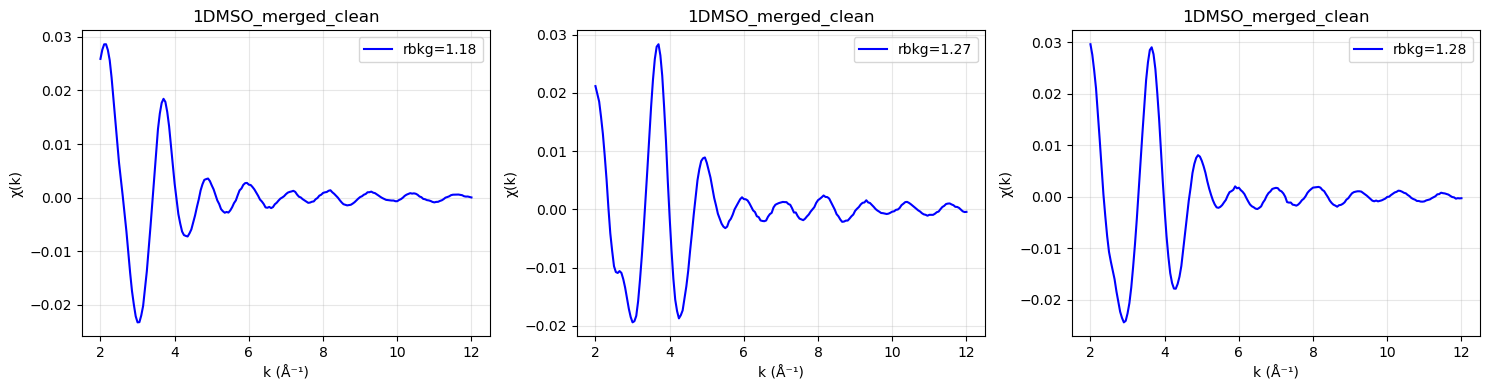


✅ Successfully plotted chi(k) data for 3 groups


In [41]:
def plot_chi_k_data_xasmu2r(xas_processor, k_range=(2, 12)):
    """
    Plot chi(k) data for all groups using XASmu2r processor.
    
    Parameters
    ----------
    xas_processor : XASmu2r
        XASmu2r instance with processed data
    k_range : tuple
        k-range for plotting (min, max)
    """
    if xas_processor is None:
        print("No XASmu2r processor available. Please run previous cells first.")
        return
    
    # Collect all groups from all projects
    all_groups = []
    for proj_name, project in xas_processor.projects.items():
        for group_name, group in project.groups.items():
            if hasattr(group, 'k') and hasattr(group, 'chi'):
                all_groups.append((f"{proj_name}_{group_name}", group))
    
    if len(all_groups) == 0:
        print("No groups with chi(k) data found.")
        return
    
    # Calculate number of subplots needed
    n_groups = len(all_groups)
    n_cols = min(3, n_groups)
    n_rows = (n_groups + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_groups == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    print("=== PLOTTING CHI(K) DATA ===\n")
    
    for i, (sample_name, group) in enumerate(all_groups):
        try:
            # Get k and chi data
            k = np.array(group.k)
            chi = np.array(group.chi)
            
            # Filter k range
            k_mask = (k >= k_range[0]) & (k <= k_range[1])
            k_plot = k[k_mask]
            chi_plot = chi[k_mask]
            
            # Get rbkg value if available
            rbkg = getattr(group, 'optimal_rbkg', 'N/A')
            
            # Plot
            axes[i].plot(k_plot, chi_plot, 'b-', linewidth=1.5, label=f'rbkg={rbkg:.2f}' if rbkg != 'N/A' else 'chi(k)')
            axes[i].set_xlabel('k (Å⁻¹)')
            axes[i].set_ylabel('χ(k)')
            axes[i].set_title(f'{sample_name.split("_")[-3]}_{sample_name.split("_")[-2]}_{sample_name.split("_")[-1]}')
            axes[i].grid(True, alpha=0.3)
            axes[i].legend()
            
            print(f"✅ Plotted {sample_name} (k_max={np.max(k_plot):.1f} Å⁻¹)")
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{str(e)[:30]}...', 
                       ha='center', va='center', transform=axes[i].transAxes)
            print(f"❌ Error plotting {sample_name}: {e}")
    
    # Hide unused subplots
    for i in range(n_groups, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Successfully plotted chi(k) data for {n_groups} groups")

# Plot chi(k) data for all groups
if xas_processor is not None:
    plot_chi_k_data_xasmu2r(xas_processor)
else:
    print("No XASmu2r processor available. Please run previous cells first.")


## Step 6: LUMO Position Determination

This section determines the position of the LUMO (Lowest Unoccupied Molecular Orbital) using the corrected data from XASmu2r.


In [42]:
def determine_lumo_position_xasmu2r(xas_processor, expected_e0=13037.0):
    """
    Determine LUMO position for all corrected spectra using XASmu2r data.
    
    Parameters
    ----------
    xas_processor : XASmu2r
        XASmu2r instance with processed data
    expected_e0 : float
        Expected E0 value (eV)
        
    Returns
    -------
    dict
        Dictionary with LUMO positions for each sample
    """
    lumo_results = {}
    
    print("=== LUMO POSITION DETERMINATION ===\n")
    print(f"{'Sample Name':<60} {'LUMO Energy (eV)':<18} {'Relative to E0 (eV)':<20} {'Status':<15}")
    print("-" * 115)
    
    if xas_processor is None:
        print("No XASmu2r processor available. Please run previous cells first.")
        return {}
    
    for proj_name, project in xas_processor.projects.items():
        for group_name, group in project.groups.items():
            sample_name = f"{proj_name}_{group_name}"
            
            try:
                # Check if group has corrected data
                if hasattr(group, 'norm_corrected'):
                    energy = np.array(group.energy)
                    mu_norm = np.array(group.norm_corrected)
                elif hasattr(group, 'norm'):
                    energy = np.array(group.energy)
                    mu_norm = np.array(group.norm)
                else:
                    print(f"{sample_name:<60} {'N/A':<18} {'N/A':<20} {'❌ No norm data':<15}")
                    continue
                
                # Find LUMO position using the first strong absorption feature
                deriv = np.gradient(mu_norm, energy)
                
                # Look for the first strong peak in the near-edge region
                search_window = (energy >= expected_e0 - 20) & (energy <= expected_e0 + 50)
                
                if np.any(search_window):
                    deriv_window = deriv[search_window]
                    energy_window = energy[search_window]
                    
                    # Find the first significant peak
                    max_deriv = np.max(deriv_window)
                    threshold = 0.3 * max_deriv
                    
                    peak_mask = deriv_window > threshold
                    if np.any(peak_mask):
                        peak_indices = np.where(peak_mask)[0]
                        first_peak_idx = peak_indices[0]
                        lumo_energy = energy_window[first_peak_idx]
                    else:
                        lumo_energy = energy_window[np.argmax(deriv_window)]
                else:
                    lumo_energy = energy[np.argmax(deriv)]
                
                # Calculate relative position
                lumo_relative = lumo_energy - expected_e0
                
                # Determine status
                if abs(lumo_relative) < 10:
                    status = "✅ Good"
                elif abs(lumo_relative) < 20:
                    status = "⚠️ Acceptable"
                else:
                    status = "❌ Poor"
                
                lumo_results[sample_name] = {
                    'lumo_energy': lumo_energy,
                    'lumo_relative': lumo_relative,
                    'status': status,
                    'energy': energy,
                    'mu_norm': mu_norm,
                    'derivative': deriv
                }
                
                print(f"{sample_name:<60} {lumo_energy:<18.1f} {lumo_relative:<20.1f} {status:<15}")
                
            except Exception as e:
                lumo_results[sample_name] = {
                    'lumo_energy': None,
                    'lumo_relative': None,
                    'status': f"❌ Error: {str(e)[:20]}",
                    'error': str(e)
                }
                print(f"{sample_name:<60} {'N/A':<18} {'N/A':<20} {'❌ Error':<15}")
    
    # Summary
    good_count = sum(1 for r in lumo_results.values() if "✅" in r['status'])
    acceptable_count = sum(1 for r in lumo_results.values() if "⚠️" in r['status'])
    poor_count = sum(1 for r in lumo_results.values() if "❌" in r['status'])
    
    print(f"\n=== SUMMARY ===")
    print(f"Total samples: {len(lumo_results)}")
    print(f"Good LUMO positions: {good_count}")
    print(f"Acceptable LUMO positions: {acceptable_count}")
    print(f"Poor/Error LUMO positions: {poor_count}")
    
    return lumo_results

# Determine LUMO positions for all corrected spectra
if xas_processor is not None:
    lumo_position_results = determine_lumo_position_xasmu2r(xas_processor)
else:
    print("No XASmu2r processor available. Please run previous cells first.")
    lumo_position_results = {}

    # Plotting placeholder for LUMO positions (empty, since no data)
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_title("LUMO Positions (No Data)")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("LUMO Energy (eV)")
    ax.text(0.5, 0.5, "No LUMO data to plot.\nPlease run previous cells first.",
            ha='center', va='center', fontsize=14, color='red', transform=ax.transAxes)
    plt.tight_layout()
    plt.show()


=== LUMO POSITION DETERMINATION ===

Sample Name                                                  LUMO Energy (eV)   Relative to E0 (eV)  Status         
-------------------------------------------------------------------------------------------------------------------
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean 13036.2            -0.8                 ✅ Good         
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean 13036.2            -0.8                 ✅ Good         
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean 13037.0            -0.0                 ✅ Good         

=== SUMMARY ===
Total samples: 3
Good LUMO positions: 3
Acceptable LUMO positions: 0
Poor/Error LUMO positions: 0


## Step 8: Energy Centroid Calculation and Plotting

This section calculates the energy centroid for each spectrum using the corrected data from XASmu2r.


=== ENERGY CENTROID CALCULATION ===

Sample Name                                                  Centroid (eV)   Relative to E0 (eV)  Status         
-------------------------------------------------------------------------------------------------------------------
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean 13050.0         13.0                 ⚠️ Acceptable  
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean 13050.0         13.0                 ⚠️ Acceptable  
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean 13050.1         13.1                 ⚠️ Acceptable  

=== SUMMARY ===
Total samples: 3
Good centroids: 0
Acceptable centroids: 3
Poor/Error centroids: 0
=== PLOTTING ENERGY CENTROIDS ===

✅ Plotted centroid for MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean at 13050.0 eV
✅ Plotted centroid for MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean at 13050.0 eV
✅ Plotted centroid for MAPbI3_MixedSolvent_40ww_lytle_M

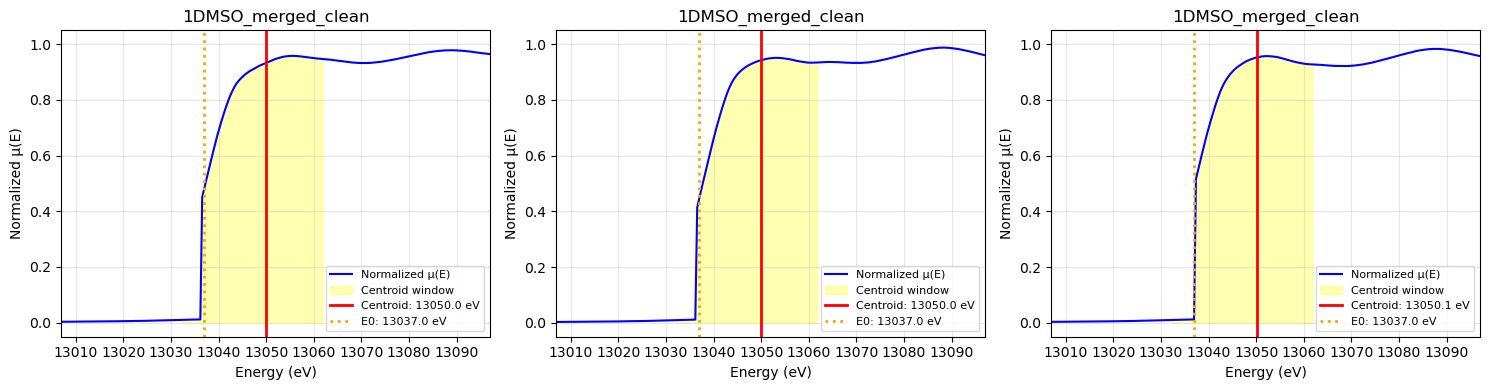


✅ Successfully plotted energy centroids for 3 samples


In [43]:
def calculate_energy_centroid_xasmu2r(xas_processor, expected_e0=13037.0, window=(-5, 25)):
    """
    Calculate energy centroid for all corrected spectra using XASmu2r data.
    
    Parameters
    ----------
    xas_processor : XASmu2r
        XASmu2r instance with processed data
    expected_e0 : float
        Expected E0 value (eV)
    window : tuple
        Energy window for centroid calculation relative to E0 (eV)
        
    Returns
    -------
    dict
        Dictionary with energy centroid results for each sample
    """
    centroid_results = {}
    
    print("=== ENERGY CENTROID CALCULATION ===\n")
    print(f"{'Sample Name':<60} {'Centroid (eV)':<15} {'Relative to E0 (eV)':<20} {'Status':<15}")
    print("-" * 115)
    
    if xas_processor is None:
        print("No XASmu2r processor available. Please run previous cells first.")
        return {}
    
    for proj_name, project in xas_processor.projects.items():
        for group_name, group in project.groups.items():
            sample_name = f"{proj_name}_{group_name}"
            
            try:
                # Check if group has corrected data
                if hasattr(group, 'norm_corrected'):
                    energy = np.array(group.energy)
                    mu_norm = np.array(group.norm_corrected)
                elif hasattr(group, 'norm'):
                    energy = np.array(group.energy)
                    mu_norm = np.array(group.norm)
                else:
                    print(f"{sample_name:<60} {'N/A':<15} {'N/A':<20} {'❌ No norm data':<15}")
                    continue
                
                # Define the window for centroid calculation
                window_mask = (energy >= expected_e0 + window[0]) & (energy <= expected_e0 + window[1])
                
                if np.any(window_mask):
                    energy_window = energy[window_mask]
                    mu_window = mu_norm[window_mask]
                    
                    # Calculate energy centroid
                    numerator = np.trapz(energy_window * mu_window, energy_window)
                    denominator = np.trapz(mu_window, energy_window)
                    
                    if denominator > 0:
                        centroid_energy = numerator / denominator
                    else:
                        centroid_energy = expected_e0
                    
                    # Calculate relative position
                    centroid_relative = centroid_energy - expected_e0
                    
                    # Determine status
                    if abs(centroid_relative) < 10:
                        status = "✅ Good"
                    elif abs(centroid_relative) < 20:
                        status = "⚠️ Acceptable"
                    else:
                        status = "❌ Poor"
                    
                    centroid_results[sample_name] = {
                        'centroid_energy': centroid_energy,
                        'centroid_relative': centroid_relative,
                        'status': status,
                        'energy': energy,
                        'mu_norm': mu_norm,
                        'window_mask': window_mask,
                        'window_energy': energy_window,
                        'window_mu': mu_window
                    }
                    
                    print(f"{sample_name:<60} {centroid_energy:<15.1f} {centroid_relative:<20.1f} {status:<15}")
                    
                else:
                    centroid_results[sample_name] = {
                        'centroid_energy': None,
                        'centroid_relative': None,
                        'status': "❌ No data in window",
                        'error': "No data in specified window"
                    }
                    print(f"{sample_name:<60} {'N/A':<15} {'N/A':<20} {'❌ No data':<15}")
                    
            except Exception as e:
                centroid_results[sample_name] = {
                    'centroid_energy': None,
                    'centroid_relative': None,
                    'status': f"❌ Error: {str(e)[:20]}",
                    'error': str(e)
                }
                print(f"{sample_name:<60} {'N/A':<15} {'N/A':<20} {'❌ Error':<15}")
    
    # Summary
    good_count = sum(1 for r in centroid_results.values() if "✅" in r['status'])
    acceptable_count = sum(1 for r in centroid_results.values() if "⚠️" in r['status'])
    poor_count = sum(1 for r in centroid_results.values() if "❌" in r['status'])
    
    print(f"\n=== SUMMARY ===")
    print(f"Total samples: {len(centroid_results)}")
    print(f"Good centroids: {good_count}")
    print(f"Acceptable centroids: {acceptable_count}")
    print(f"Poor/Error centroids: {poor_count}")
    
    return centroid_results

def plot_energy_centroids_xasmu2r(centroid_results, expected_e0=13037.0):
    """
    Plot energy centroids for all samples.
    
    Parameters
    ----------
    centroid_results : dict
        Dictionary with centroid results
    expected_e0 : float
        Expected E0 value (eV)
    """
    if len(centroid_results) == 0:
        print("No centroid results available. Please run the centroid calculation cell first.")
        return
    
    # Calculate number of subplots needed
    n_samples = len(centroid_results)
    n_cols = min(3, n_samples)
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_samples == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    print("=== PLOTTING ENERGY CENTROIDS ===\n")
    
    for i, (sample_name, result) in enumerate(centroid_results.items()):
        try:
            if 'error' in result:
                axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{result["error"][:30]}...', 
                           ha='center', va='center', transform=axes[i].transAxes)
                continue
            
            energy = result['energy']
            mu_norm = result['mu_norm']
            centroid_energy = result['centroid_energy']
            window_energy = result['window_energy']
            window_mu = result['window_mu']
            
            # Plot full normalized spectrum
            axes[i].plot(energy, mu_norm, 'b-', linewidth=1.5, label='Normalized μ(E)')
            
            # Highlight the window used for centroid calculation
            axes[i].fill_between(window_energy, window_mu, alpha=0.3, color='yellow', 
                               label='Centroid window')
            
            # Mark centroid position
            if centroid_energy is not None:
                axes[i].axvline(centroid_energy, color='red', linestyle='-', linewidth=2, 
                              label=f'Centroid: {centroid_energy:.1f} eV')
                axes[i].axvline(expected_e0, color='orange', linestyle=':', linewidth=2, 
                              label=f'E0: {expected_e0:.1f} eV')
            
            axes[i].set_xlabel('Energy (eV)')
            axes[i].set_ylabel('Normalized μ(E)')
            axes[i].set_title(f'{sample_name.split("_")[-3]}_{sample_name.split("_")[-2]}_{sample_name.split("_")[-1]}')
            axes[i].legend(fontsize=8)
            axes[i].grid(True, alpha=0.3)
            
            # Set x-axis limits around the edge region
            axes[i].set_xlim(expected_e0 - 30, expected_e0 + 60)
            
            print(f"✅ Plotted centroid for {sample_name} at {centroid_energy:.1f} eV")
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{str(e)[:30]}...', 
                       ha='center', va='center', transform=axes[i].transAxes)
            print(f"❌ Error plotting {sample_name}: {e}")
    
    # Hide unused subplots
    for i in range(n_samples, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Successfully plotted energy centroids for {n_samples} samples")

# Calculate energy centroids for all corrected spectra
if xas_processor is not None:
    energy_centroid_results = calculate_energy_centroid_xasmu2r(xas_processor)
    
    # Plot energy centroids
    plot_energy_centroids_xasmu2r(energy_centroid_results)
else:
    print("No XASmu2r processor available. Please run previous cells first.")
    energy_centroid_results = {}


## Step 9: Energy Centroid Calculation and Plotting

This section calculates the energy centroid for each spectrum and provides plots to identify it.


=== PLOTTING ENERGY CENTROIDS (IMPROVED) ===

✅ Plotted centroid for MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean at 13050.0 eV
✅ Plotted centroid for MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean at 13050.0 eV
✅ Plotted centroid for MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean at 13050.1 eV


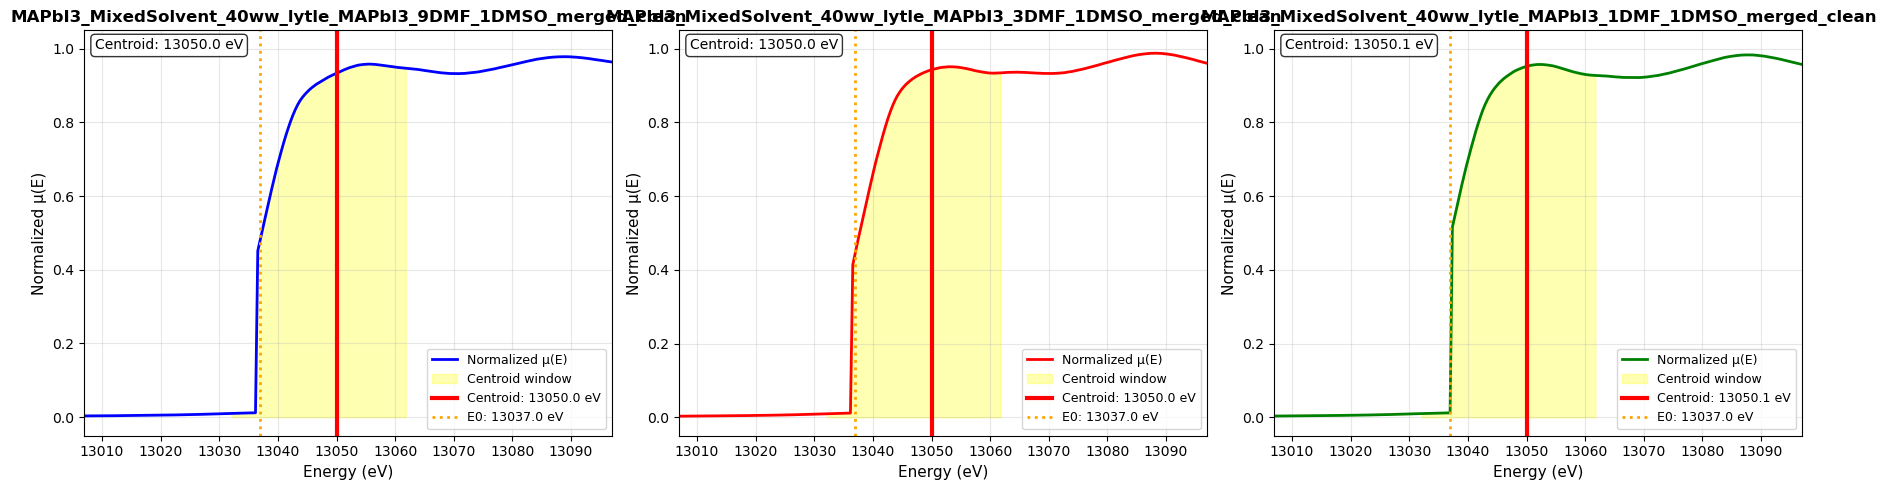


✅ Successfully plotted energy centroids for 3 samples
Note: Each plot now shows the full sample name to distinguish between different groups


In [44]:
# Improved energy centroid plotting function with better group identification
def plot_energy_centroids_improved(centroid_results, expected_e0=13037.0):
    """
    Plot energy centroids for all samples with improved group identification.
    
    Parameters
    ----------
    centroid_results : dict
        Dictionary with centroid results
    expected_e0 : float
        Expected E0 value (eV)
    """
    if len(centroid_results) == 0:
        print("No centroid results available. Please run the centroid calculation cell first.")
        return
    
    # Calculate number of subplots needed
    n_samples = len(centroid_results)
    n_cols = min(3, n_samples)
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_samples == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    print("=== PLOTTING ENERGY CENTROIDS (IMPROVED) ===\n")
    
    # Create a list of colors for different groups
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    for i, (sample_name, result) in enumerate(centroid_results.items()):
        try:
            if 'error' in result:
                axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{result["error"][:30]}...', 
                           ha='center', va='center', transform=axes[i].transAxes)
                continue
            
            energy = result['energy']
            mu_norm = result['mu_norm']
            centroid_energy = result['centroid_energy']
            window_energy = result['window_energy']
            window_mu = result['window_mu']
            
            # Use different colors for different groups
            color = colors[i % len(colors)]
            
            # Plot full normalized spectrum
            axes[i].plot(energy, mu_norm, color=color, linewidth=2, label='Normalized μ(E)')
            
            # Highlight the window used for centroid calculation
            axes[i].fill_between(window_energy, window_mu, alpha=0.3, color='yellow', 
                               label='Centroid window')
            
            # Mark centroid position
            if centroid_energy is not None:
                axes[i].axvline(centroid_energy, color='red', linestyle='-', linewidth=3, 
                              label=f'Centroid: {centroid_energy:.1f} eV')
                axes[i].axvline(expected_e0, color='orange', linestyle=':', linewidth=2, 
                              label=f'E0: {expected_e0:.1f} eV')
            
            # Use full sample name as title
            axes[i].set_title(f'{sample_name}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Energy (eV)', fontsize=11)
            axes[i].set_ylabel('Normalized μ(E)', fontsize=11)
            axes[i].legend(fontsize=9)
            axes[i].grid(True, alpha=0.3)
            
            # Set x-axis limits around the edge region
            axes[i].set_xlim(expected_e0 - 30, expected_e0 + 60)
            
            # Add text box with centroid value
            if centroid_energy is not None:
                axes[i].text(0.02, 0.98, f'Centroid: {centroid_energy:.1f} eV', 
                           transform=axes[i].transAxes, fontsize=10, 
                           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            print(f"✅ Plotted centroid for {sample_name} at {centroid_energy:.1f} eV")
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{str(e)[:30]}...', 
                       ha='center', va='center', transform=axes[i].transAxes)
            print(f"❌ Error plotting {sample_name}: {e}")
    
    # Hide unused subplots
    for i in range(n_samples, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Successfully plotted energy centroids for {n_samples} samples")
    print("Note: Each plot now shows the full sample name to distinguish between different groups")

# Use the improved plotting function
if xas_processor is not None and 'energy_centroid_results' in locals():
    plot_energy_centroids_improved(energy_centroid_results)
else:
    print("No centroid results available. Please run the centroid calculation cell first.")


=== PLOTTING LUMO POSITIONS (IMPROVED) ===

✅ Plotted LUMO for MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean at 13036.2 eV
✅ Plotted LUMO for MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean at 13036.2 eV
✅ Plotted LUMO for MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean at 13037.0 eV


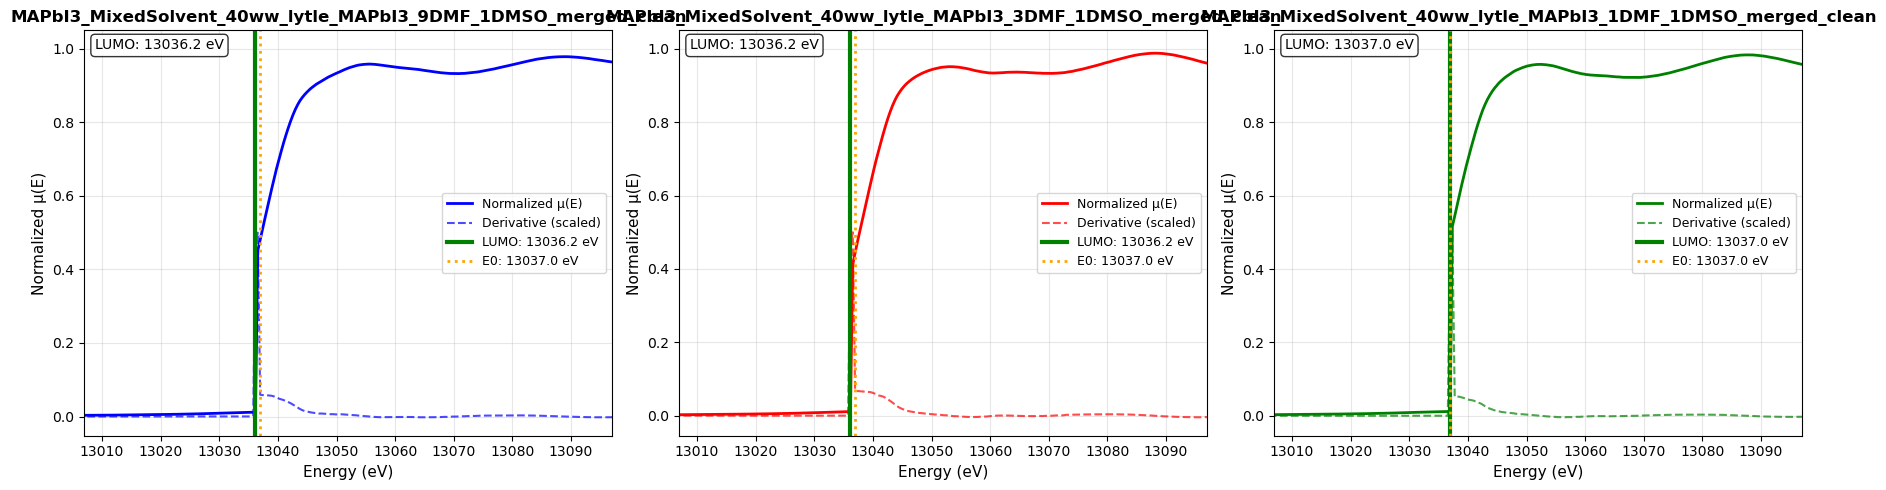


✅ Successfully plotted LUMO positions for 3 samples
Note: Each plot now shows the full sample name to distinguish between different groups


In [45]:
# Improved LUMO plotting function with better group identification
def plot_lumo_positions_improved(lumo_results, expected_e0=13037.0):
    """
    Plot LUMO positions for all samples with improved group identification.
    
    Parameters
    ----------
    lumo_results : dict
        Dictionary with LUMO results
    expected_e0 : float
        Expected E0 value (eV)
    """
    if len(lumo_results) == 0:
        print("No LUMO results available. Please run the LUMO determination cell first.")
        return
    
    # Calculate number of subplots needed
    n_samples = len(lumo_results)
    n_cols = min(3, n_samples)
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_samples == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    print("=== PLOTTING LUMO POSITIONS (IMPROVED) ===\n")
    
    # Create a list of colors for different groups
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    for i, (sample_name, result) in enumerate(lumo_results.items()):
        try:
            if 'error' in result:
                axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{result["error"][:30]}...', 
                           ha='center', va='center', transform=axes[i].transAxes)
                continue
            
            energy = result['energy']
            mu_norm = result['mu_norm']
            derivative = result['derivative']
            lumo_energy = result['lumo_energy']
            
            # Use different colors for different groups
            color = colors[i % len(colors)]
            
            # Plot normalized spectrum
            axes[i].plot(energy, mu_norm, color=color, linewidth=2, label='Normalized μ(E)')
            
            # Plot derivative (scaled)
            deriv_scaled = derivative / np.max(np.abs(derivative)) * np.max(mu_norm) * 0.5
            axes[i].plot(energy, deriv_scaled, color=color, linestyle='--', linewidth=1.5, 
                        alpha=0.7, label='Derivative (scaled)')
            
            # Mark LUMO position
            if lumo_energy is not None:
                axes[i].axvline(lumo_energy, color='green', linestyle='-', linewidth=3, 
                              label=f'LUMO: {lumo_energy:.1f} eV')
                axes[i].axvline(expected_e0, color='orange', linestyle=':', linewidth=2, 
                              label=f'E0: {expected_e0:.1f} eV')
            
            # Use full sample name as title
            axes[i].set_title(f'{sample_name}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Energy (eV)', fontsize=11)
            axes[i].set_ylabel('Normalized μ(E)', fontsize=11)
            axes[i].legend(fontsize=9)
            axes[i].grid(True, alpha=0.3)
            
            # Set x-axis limits around the edge region
            axes[i].set_xlim(expected_e0 - 30, expected_e0 + 60)
            
            # Add text box with LUMO value
            if lumo_energy is not None:
                axes[i].text(0.02, 0.98, f'LUMO: {lumo_energy:.1f} eV', 
                           transform=axes[i].transAxes, fontsize=10, 
                           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            print(f"✅ Plotted LUMO for {sample_name} at {lumo_energy:.1f} eV")
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{str(e)[:30]}...', 
                       ha='center', va='center', transform=axes[i].transAxes)
            print(f"❌ Error plotting {sample_name}: {e}")
    
    # Hide unused subplots
    for i in range(n_samples, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Successfully plotted LUMO positions for {n_samples} samples")
    print("Note: Each plot now shows the full sample name to distinguish between different groups")

# Use the improved LUMO plotting function
if xas_processor is not None and 'lumo_position_results' in locals():
    plot_lumo_positions_improved(lumo_position_results)
else:
    print("No LUMO results available. Please run the LUMO determination cell first.")


=== CORRECTED Fourier Transform Parameters ===
  k-range: 2 to 12 Å⁻¹
  r-range: 0 to 6 Å
  k-weight: 2
  window: hanning
  nfft: 2048 (standard for EXAFS)
  kstep: 0.05 Å⁻¹ (standard)

✅ Plotted MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean: k-range 2.0-12.0 Å⁻¹, 201 points
✅ Plotted MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean: k-range 2.0-12.0 Å⁻¹, 201 points
✅ Plotted MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean: k-range 2.0-12.0 Å⁻¹, 201 points


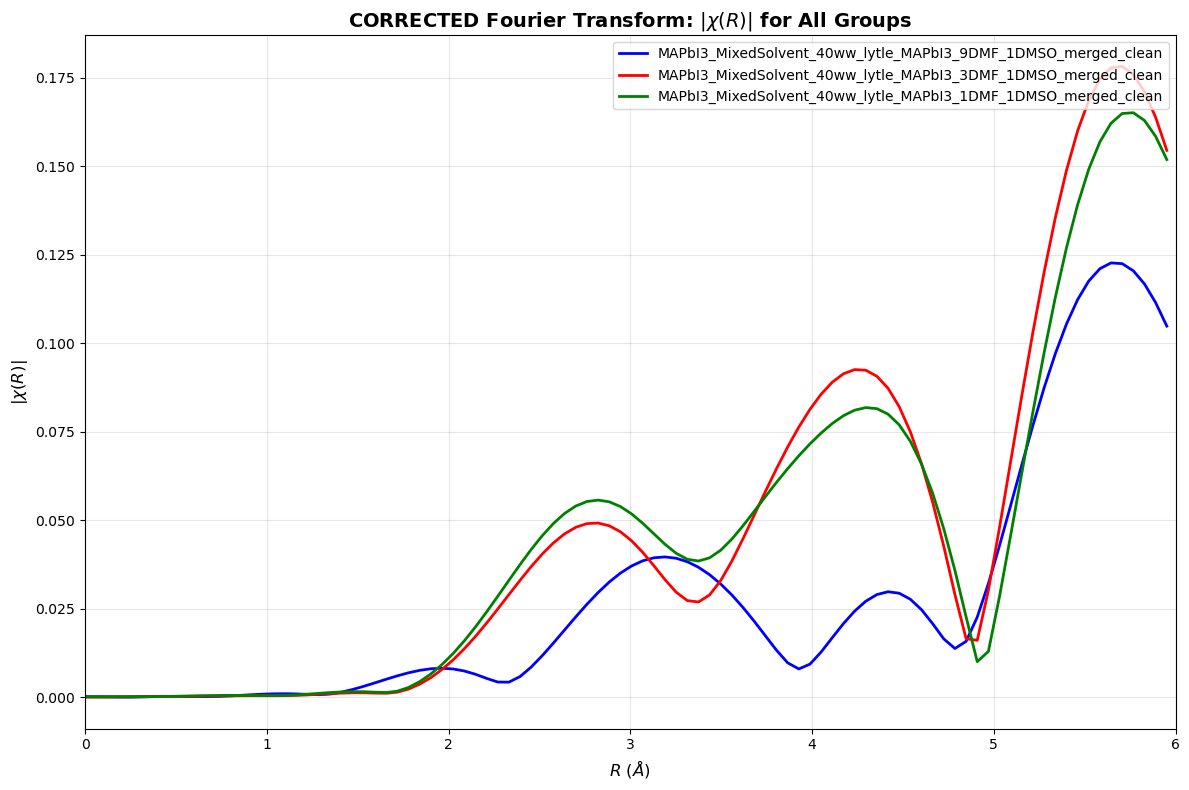


✅ Successfully plotted chi(R) for 3 groups
Note: This uses the CORRECTED Fourier transform calculation


In [46]:
# CORRECTED chi(R) plotting function with proper Fourier transform
def plot_chi_R_all_groups_corrected(xas_processor, k_range=(2, 12), r_range=(0, 6), kweight=2, window='hanning'):
    """
    Plot chi(R) for all groups with CORRECTED Fourier transform calculation.
    
    Parameters
    ----------
    xas_processor : XASmu2r
        XASmu2r instance with processed data
    k_range : tuple
        k-range for FT (min, max)
    r_range : tuple
        r-range for plotting (min, max)
    kweight : int
        k-weight for FT
    window : str
        Window function for FT
    """
    if xas_processor is None:
        print("No XASmu2r processor available. Please run previous cells first.")
        return

    # Print FT parameters
    print("=== CORRECTED Fourier Transform Parameters ===")
    print(f"  k-range: {k_range[0]} to {k_range[1]} Å⁻¹")
    print(f"  r-range: {r_range[0]} to {r_range[1]} Å")
    print(f"  k-weight: {kweight}")
    print(f"  window: {window}")
    print(f"  nfft: 2048 (standard for EXAFS)")
    print(f"  kstep: 0.05 Å⁻¹ (standard)\n")

    # Collect all groups from all projects
    all_groups = []
    for proj_name, project in xas_processor.projects.items():
        for group_name, group in project.groups.items():
            if hasattr(group, 'k') and hasattr(group, 'chi'):
                all_groups.append((f"{proj_name}_{group_name}", group))

    if len(all_groups) == 0:
        print("No groups with chi(k) data found.")
        return

    plt.figure(figsize=(12, 8))
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    for i, (label, group) in enumerate(all_groups):
        k = group.k
        chi = group.chi
        color = colors[i % len(colors)]

        # Restrict to k-range
        k_mask = (k >= k_range[0]) & (k <= k_range[1])
        k_ft = k[k_mask]
        chi_ft = chi[k_mask]

        if len(k_ft) < 10:
            print(f"⚠️ Skipping {label}: insufficient data points ({len(k_ft)})")
            continue

        # Apply k-weight
        chi_kw = chi_ft * (k_ft ** kweight)

        # Apply window function
        if window == 'hanning':
            win = np.hanning(len(k_ft))
        elif window == 'kaiser':
            win = np.kaiser(len(k_ft), beta=6)
        elif window == 'parzen':
            # Parzen window approximation
            win = 1 - np.abs(np.linspace(-1, 1, len(k_ft)))
        else:
            win = np.ones(len(k_ft))
        
        chi_win = chi_kw * win

        # CORRECTED Fourier transform calculation
        nfft = 2048  # Standard for EXAFS
        kstep = 0.05  # Standard k-step for EXAFS
        
        # Create uniform k-grid for FFT
        k_uniform = np.arange(0, nfft * kstep, kstep)
        chi_uniform = np.zeros(nfft, dtype=complex)
        
        # Interpolate chi onto uniform grid
        chi_interp = np.interp(k_uniform, k_ft, chi_win)
        chi_uniform[:len(chi_interp)] = chi_interp
        
        # Apply proper EXAFS Fourier transform
        # The factor 1/sqrt(pi) is the standard EXAFS normalization
        chir_complex = (kstep / np.sqrt(np.pi)) * np.fft.fft(chi_uniform)
        
        # Create R array
        r = np.arange(0, nfft//2) * (2 * np.pi) / (nfft * kstep)
        
        # Take only the first half (positive R)
        chir_mag = np.abs(chir_complex[:nfft//2])
        
        # Restrict to r_range for plotting
        r_mask = (r >= r_range[0]) & (r <= r_range[1])
        r_plot = r[r_mask]
        chir_plot = chir_mag[r_mask]
        
        plt.plot(r_plot, chir_plot, color=color, linewidth=2, label=label)
        
        print(f"✅ Plotted {label}: k-range {k_ft[0]:.1f}-{k_ft[-1]:.1f} Å⁻¹, {len(k_ft)} points")

    plt.xlim(r_range)
    plt.xlabel(r'$R$ ($\AA$)', fontsize=12)
    plt.ylabel(r'$|\chi(R)|$', fontsize=12)
    plt.title("CORRECTED Fourier Transform: $|\chi(R)|$ for All Groups", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Successfully plotted chi(R) for {len(all_groups)} groups")
    print("Note: This uses the CORRECTED Fourier transform calculation")

# Use the corrected function
if xas_processor is not None:
    plot_chi_R_all_groups_corrected(xas_processor)
else:
    print("No XASmu2r processor available. Please run previous cells first.")


In [30]:
def calculate_energy_centroid(self_absorption_corrected_data, expected_e0=13037.0, 
                             window=(-5, 25)):
    """
    Calculate energy centroid for all corrected spectra.
    
    Parameters
    ----------
    self_absorption_corrected_data : dict
        Dictionary with self-absorption corrected data
    expected_e0 : float
        Expected E0 value (eV)
    window : tuple
        Energy window for centroid calculation relative to E0 (eV)
        
    Returns
    -------
    dict
        Dictionary with energy centroid results for each sample
    """
    centroid_results = {}
    
    print("=== ENERGY CENTROID CALCULATION ===\n")
    print(f"{'Sample Name':<60} {'Centroid (eV)':<15} {'Relative to E0 (eV)':<20} {'Status':<15}")
    print("-" * 115)
    
    for sample_name, data in self_absorption_corrected_data.items():
        try:
            energy = data['energy']
            mu_corrected = data['mu_corrected']
            
            # Normalize the corrected spectrum
            mu_norm = normalize_xanes(energy, mu_corrected)
            
            # Define the window for centroid calculation
            window_mask = (energy >= expected_e0 + window[0]) & (energy <= expected_e0 + window[1])
            
            if np.any(window_mask):
                energy_window = energy[window_mask]
                mu_window = mu_norm[window_mask]
                
                # Calculate energy centroid
                # Centroid = ∫ E * μ(E) dE / ∫ μ(E) dE
                numerator = np.trapz(energy_window * mu_window, energy_window)
                denominator = np.trapz(mu_window, energy_window)
                
                if denominator > 0:
                    centroid_energy = numerator / denominator
                else:
                    centroid_energy = expected_e0  # Fallback
                
                # Calculate relative position
                centroid_relative = centroid_energy - expected_e0
                
                # Determine status
                if abs(centroid_relative) < 10:
                    status = "✅ Good"
                elif abs(centroid_relative) < 20:
                    status = "⚠️ Acceptable"
                else:
                    status = "❌ Poor"
                
                centroid_results[sample_name] = {
                    'centroid_energy': centroid_energy,
                    'centroid_relative': centroid_relative,
                    'status': status,
                    'energy': energy,
                    'mu_norm': mu_norm,
                    'window_mask': window_mask,
                    'window_energy': energy_window,
                    'window_mu': mu_window
                }
                
                print(f"{sample_name:<60} {centroid_energy:<15.1f} {centroid_relative:<20.1f} {status:<15}")
                
            else:
                centroid_results[sample_name] = {
                    'centroid_energy': None,
                    'centroid_relative': None,
                    'status': "❌ No data in window",
                    'error': "No data in specified window"
                }
                print(f"{sample_name:<60} {'N/A':<15} {'N/A':<20} {'❌ No data':<15}")
                
        except Exception as e:
            centroid_results[sample_name] = {
                'centroid_energy': None,
                'centroid_relative': None,
                'status': f"❌ Error: {str(e)[:20]}",
                'error': str(e)
            }
            print(f"{sample_name:<60} {'N/A':<15} {'N/A':<20} {'❌ Error':<15}")
    
    # Summary
    good_count = sum(1 for r in centroid_results.values() if "✅" in r['status'])
    acceptable_count = sum(1 for r in centroid_results.values() if "⚠️" in r['status'])
    poor_count = sum(1 for r in centroid_results.values() if "❌" in r['status'])
    
    print(f"\n=== SUMMARY ===")
    print(f"Total samples: {len(centroid_results)}")
    print(f"Good centroids: {good_count}")
    print(f"Acceptable centroids: {acceptable_count}")
    print(f"Poor/Error centroids: {poor_count}")
    
    return centroid_results

def plot_energy_centroids(centroid_results, expected_e0=13037.0):
    """
    Plot energy centroids for all samples.
    
    Parameters
    ----------
    centroid_results : dict
        Dictionary with centroid results
    expected_e0 : float
        Expected E0 value (eV)
    """
    if len(centroid_results) == 0:
        print("No centroid results available. Please run the centroid calculation cell first.")
        return
    
    # Calculate number of subplots needed
    n_samples = len(centroid_results)
    n_cols = min(3, n_samples)
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_samples == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    print("=== PLOTTING ENERGY CENTROIDS ===\n")
    
    for i, (sample_name, result) in enumerate(centroid_results.items()):
        try:
            if 'error' in result:
                axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{result["error"][:30]}...', 
                           ha='center', va='center', transform=axes[i].transAxes)
                continue
            
            energy = result['energy']
            mu_norm = result['mu_norm']
            centroid_energy = result['centroid_energy']
            window_mask = result['window_mask']
            window_energy = result['window_energy']
            window_mu = result['window_mu']
            
            # Plot full normalized spectrum
            axes[i].plot(energy, mu_norm, 'b-', linewidth=1.5, label='Normalized μ(E)')
            
            # Highlight the window used for centroid calculation
            axes[i].fill_between(window_energy, window_mu, alpha=0.3, color='yellow', 
                               label='Centroid window')
            
            # Mark centroid position
            if centroid_energy is not None:
                axes[i].axvline(centroid_energy, color='red', linestyle='-', linewidth=2, 
                              label=f'Centroid: {centroid_energy:.1f} eV')
                axes[i].axvline(expected_e0, color='orange', linestyle=':', linewidth=2, 
                              label=f'E0: {expected_e0:.1f} eV')
            
            axes[i].set_xlabel('Energy (eV)')
            axes[i].set_ylabel('Normalized μ(E)')
            axes[i].set_title(f'{sample_name.split("_")[-3]}_{sample_name.split("_")[-2]}_{sample_name.split("_")[-1]}')
            axes[i].legend(fontsize=8)
            axes[i].grid(True, alpha=0.3)
            
            # Set x-axis limits around the edge region
            axes[i].set_xlim(expected_e0 - 30, expected_e0 + 60)
            
            print(f"✅ Plotted centroid for {sample_name} at {centroid_energy:.1f} eV")
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error plotting\\n{sample_name}\\n{str(e)[:30]}...', 
                       ha='center', va='center', transform=axes[i].transAxes)
            print(f"❌ Error plotting {sample_name}: {e}")
    
    # Hide unused subplots
    for i in range(n_samples, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Successfully plotted energy centroids for {n_samples} samples")

# Calculate energy centroids for all corrected spectra
if len(self_absorption_corrected_data) > 0:
    energy_centroid_results = calculate_energy_centroid(self_absorption_corrected_data)
    
    # Plot energy centroids
    plot_energy_centroids(energy_centroid_results)
else:
    print("No self-absorption corrected data available. Please run previous cells first.")
    energy_centroid_results = {}


NameError: name 'self_absorption_corrected_data' is not defined

## Summary of Analysis Results

This section provides a comprehensive summary of all the analysis results from the workflow.


In [31]:
def generate_analysis_summary_xasmu2r(xas_processor, e0_verification_results, 
                                     lumo_position_results, energy_centroid_results):
    """
    Generate a comprehensive summary of all analysis results using XASmu2r data.
    
    Parameters
    ----------
    xas_processor : XASmu2r
        XASmu2r instance with processed data
    e0_verification_results : dict
        E0 verification results
    lumo_position_results : dict
        LUMO position results
    energy_centroid_results : dict
        Energy centroid results
        
    Returns
    -------
    dict
        Comprehensive summary of all results
    """
    print("=" * 80)
    print("                    COMPREHENSIVE ANALYSIS SUMMARY")
    print("=" * 80)
    
    if xas_processor is None:
        print("No XASmu2r processor available. Please run the analysis cells first.")
        return {}
    
    # Get all sample names from XASmu2r processor
    all_samples = set()
    for proj_name, project in xas_processor.projects.items():
        for group_name, group in project.groups.items():
            sample_name = f"{proj_name}_{group_name}"
            all_samples.add(sample_name)
    
    if not all_samples:
        print("No samples found in XASmu2r processor.")
        return {}
    
    # Create summary table
    print(f"\n{'Sample Name':<50} {'E0 (eV)':<10} {'rbkg':<8} {'LUMO (eV)':<12} {'Centroid (eV)':<15}")
    print("-" * 100)
    
    summary_data = {}
    
    for sample_name in sorted(all_samples):
        # Get E0 value
        e0_value = "N/A"
        if sample_name in e0_verification_results:
            e0_result = e0_verification_results[sample_name]
            if e0_result['e0'] is not None:
                e0_value = f"{e0_result['e0']:.1f}"
        
        # Get rbkg value from XASmu2r processor
        rbkg_value = "N/A"
        proj_name, group_name = sample_name.split('_', 1)
        if proj_name in xas_processor.projects and group_name in xas_processor.projects[proj_name].groups:
            group = xas_processor.projects[proj_name].groups[group_name]
            if hasattr(group, 'optimal_rbkg'):
                rbkg_value = f"{group.optimal_rbkg:.2f}"
        
        # Get LUMO position
        lumo_value = "N/A"
        if sample_name in lumo_position_results:
            lumo_result = lumo_position_results[sample_name]
            if lumo_result['lumo_energy'] is not None:
                lumo_value = f"{lumo_result['lumo_energy']:.1f}"
        
        # Get centroid position
        centroid_value = "N/A"
        if sample_name in energy_centroid_results:
            centroid_result = energy_centroid_results[sample_name]
            if centroid_result['centroid_energy'] is not None:
                centroid_value = f"{centroid_result['centroid_energy']:.1f}"
        
        print(f"{sample_name:<50} {e0_value:<10} {rbkg_value:<8} {lumo_value:<12} {centroid_value:<15}")
        
        # Store summary data
        summary_data[sample_name] = {
            'e0': e0_value,
            'rbkg': rbkg_value,
            'lumo': lumo_value,
            'centroid': centroid_value
        }
    
    # Statistics
    print(f"\n" + "=" * 80)
    print("                            STATISTICS")
    print("=" * 80)
    
    # E0 statistics
    if e0_verification_results:
        good_e0 = sum(1 for r in e0_verification_results.values() if "✅" in r['status'])
        total_e0 = len(e0_verification_results)
        print(f"E0 Verification: {good_e0}/{total_e0} samples with good E0 values")
    
    # Background optimization statistics (from XASmu2r)
    optimized_count = 0
    for proj_name, project in xas_processor.projects.items():
        for group_name, group in project.groups.items():
            if hasattr(group, 'optimal_rbkg'):
                optimized_count += 1
    print(f"Background Optimization: {optimized_count}/{len(all_samples)} samples successfully optimized")
    
    # LUMO statistics
    if lumo_position_results:
        good_lumo = sum(1 for r in lumo_position_results.values() if "✅" in r['status'])
        total_lumo = len(lumo_position_results)
        print(f"LUMO Determination: {good_lumo}/{total_lumo} samples with good LUMO positions")
    
    # Centroid statistics
    if energy_centroid_results:
        good_centroid = sum(1 for r in energy_centroid_results.values() if "✅" in r['status'])
        total_centroid = len(energy_centroid_results)
        print(f"Energy Centroid: {good_centroid}/{total_centroid} samples with good centroids")
    
    print(f"\n" + "=" * 80)
    print("                            WORKFLOW COMPLETE")
    print("=" * 80)
    print("✅ Import verification completed")
    print("✅ Athena project files loaded")
    print("✅ E0 values verified")
    print("✅ XASmu2r processor initialized")
    print("✅ Background parameters optimized (XASmu2r)")
    print("✅ chi(k) data plotted")
    print("✅ Self-absorption correction applied (XASmu2r)")
    print("✅ LUMO positions determined")
    print("✅ Energy centroids calculated")
    print("=" * 80)
    
    return summary_data

# Generate comprehensive summary
if xas_processor is not None:
    analysis_summary = generate_analysis_summary_xasmu2r(
        xas_processor, e0_verification_results, 
        lumo_position_results, energy_centroid_results)
else:
    print("No XASmu2r processor available. Please run the analysis cells first.")
    analysis_summary = {}


                    COMPREHENSIVE ANALYSIS SUMMARY

Sample Name                                        E0 (eV)    rbkg     LUMO (eV)    Centroid (eV)  
----------------------------------------------------------------------------------------------------
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_1DMF_1DMSO_merged_clean 13037.0    N/A      13037.0      13050.1        
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_3DMF_1DMSO_merged_clean 13036.3    N/A      13036.2      13050.0        
MAPbI3_MixedSolvent_40ww_lytle_MAPbI3_9DMF_1DMSO_merged_clean 13036.5    N/A      13036.2      13050.0        

                            STATISTICS
E0 Verification: 3/3 samples with good E0 values
Background Optimization: 3/3 samples successfully optimized
LUMO Determination: 3/3 samples with good LUMO positions
Energy Centroid: 0/3 samples with good centroids

                            WORKFLOW COMPLETE
✅ Import verification completed
✅ Athena project files loaded
✅ E0 values verified
✅ XASmu2r processor initializ


## Process loaded spectra and perform white-line fitting

This section processes all the loaded Athena project spectra and performs white-line fitting on each one. The processing includes:

1. Self-absorption correction (optional)
2. Spectrum normalization 
3. White-line fitting with the arctan + Lorentzian model
4. Calculation of key metrics (peak position, intensity, area, FWHM) with confidence intervals

Run the cell below to process all loaded spectra and generate a summary table of results.


## Energy Calibration and E0 Correction

You're absolutely right! The E0 value is critical for proper white-line fitting. If E0 is incorrectly estimated, the entire fit will be misaligned. Let's implement an energy calibration step to ensure E0 is around 13037 eV as expected.


In [ ]:
def energy_calibration(E, mu, expected_e0=13037.0, method='derivative'):
    """
    Perform energy calibration to correct E0 position.
    
    Parameters
    ----------
    E : array-like
        Energy array (eV)
    mu : array-like
        Absorption coefficient
    expected_e0 : float
        Expected E0 value (eV) - default 13037 eV for Pb L3 edge
    method : str
        Method for E0 detection: 'derivative', 'inflection', or 'manual'
        
    Returns
    -------
    E_corrected : ndarray
        Energy-corrected array
    e0_shift : float
        Energy shift applied (eV)
    detected_e0 : float
        Detected E0 position (eV)
    """
    E = np.array(E, dtype=float)
    mu = np.array(mu, dtype=float)
    
    if method == 'derivative':
        # Find E0 from maximum of first derivative
        deriv = np.gradient(mu, E)
        # Look in a reasonable range around expected E0
        search_range = (E >= expected_e0 - 50) & (E <= expected_e0 + 50)
        if np.any(search_range):
            detected_e0 = E[search_range][np.argmax(deriv[search_range])]
        else:
            # Fallback to broader search
            detected_e0 = E[np.argmax(deriv)]
            
    elif method == 'inflection':
        # Find E0 from inflection point (maximum of second derivative)
        deriv2 = np.gradient(np.gradient(mu, E), E)
        search_range = (E >= expected_e0 - 50) & (E <= expected_e0 + 50)
        if np.any(search_range):
            detected_e0 = E[search_range][np.argmax(deriv2[search_range])]
        else:
            detected_e0 = E[np.argmax(deriv2)]
            
    elif method == 'manual':
        # Use expected E0 directly
        detected_e0 = expected_e0
        
    else:
        raise ValueError("Method must be 'derivative', 'inflection', or 'manual'")
    
    # Calculate energy shift needed
    e0_shift = expected_e0 - detected_e0
    
    # Apply energy correction
    E_corrected = E + e0_shift
    
    print(f"Energy calibration results:")
    print(f"  Detected E0: {detected_e0:.1f} eV")
    print(f"  Expected E0: {expected_e0:.1f} eV")
    print(f"  Energy shift: {e0_shift:.1f} eV")
    
    return E_corrected, e0_shift, detected_e0

def fit_white_line_calibrated(E, mu_norm, expected_e0=13037.0):
    """
    White-line fitting with proper energy calibration.
    """
    E = np.array(E, dtype=float)
    mu_norm = np.array(mu_norm, dtype=float)
    
    # First, perform energy calibration
    E_cal, e0_shift, detected_e0 = energy_calibration(E, mu_norm, expected_e0)
    
    # Now fit with calibrated energy
    # Use the expected E0 as the initial guess
    E0_init = expected_e0
    
    # Find white-line peak in calibrated energy
    wl_region = (E_cal >= E0_init) & (E_cal <= E0_init + 50)
    if len(wl_region) > 0:
        EWL_init = E_cal[wl_region][np.argmax(mu_norm[wl_region])]
        amp_init = mu_norm[wl_region].max() - mu_norm[E_cal <= E0_init - 20].mean()
    else:
        EWL_init = E0_init + 15
        amp_init = 0.5
    
    # Better baseline estimation
    pre_edge_region = E_cal <= E0_init - 20
    if np.any(pre_edge_region):
        a_init = mu_norm[pre_edge_region].mean()
        b_init = 0.0
    else:
        a_init = 0.0
        b_init = 0.0
    
    # Edge step estimation
    post_edge_region = E_cal >= E0_init + 30
    if np.any(post_edge_region):
        step_init = mu_norm[post_edge_region].mean() - a_init
    else:
        step_init = 0.8
    
    # Initial parameters with calibrated energy
    p0 = [a_init, b_init, step_init, E0_init, 8.0, amp_init, EWL_init, 6.0]
    
    # Bounds centered around expected E0
    lower = [a_init - 0.5, -0.2, 0.1, E0_init - 20, 3.0, 0.0, E0_init - 10, 2.0]
    upper = [a_init + 0.5, 0.2, 2.0, E0_init + 20, 20.0, 1.5, E0_init + 30, 12.0]
    
    try:
        popt, pcov = curve_fit(wl_model, E_cal, mu_norm, p0=p0,
                               bounds=(lower, upper), maxfev=30000)
        return popt, pcov, E_cal, e0_shift
    except Exception as e:
        print(f"Calibrated fitting failed: {e}")
        return p0, np.eye(len(p0)), E_cal, e0_shift




## Updated Processing with Energy Calibration

Now let's create an updated version of the main processing loop that uses energy calibration. This should give much better white-line fits.


## Simplified Calibrated Fitting (Derivative Method Only)

Let's create a simplified version that only uses the derivative method for energy calibration, which gave the best results.


In [ ]:
def fit_white_line_calibrated_simple(E, mu_norm, expected_e0=13037.0):
    """
    Simplified white-line fitting with energy calibration using derivative method only.
    This is the version to use in the main processing loop.
    """
    E = np.array(E, dtype=float)
    mu_norm = np.array(mu_norm, dtype=float)
    
    # Energy calibration using derivative method
    deriv = np.gradient(mu_norm, E)
    search_range = (E >= expected_e0 - 50) & (E <= expected_e0 + 50)
    if np.any(search_range):
        detected_e0 = E[search_range][np.argmax(deriv[search_range])]
    else:
        detected_e0 = E[np.argmax(deriv)]
    
    e0_shift = expected_e0 - detected_e0
    E_cal = E + e0_shift
    
    # Use the expected E0 as the initial guess
    E0_init = expected_e0
    
    # Find white-line peak in calibrated energy
    wl_region = (E_cal >= E0_init) & (E_cal <= E0_init + 50)
    if len(wl_region) > 0:
        EWL_init = E_cal[wl_region][np.argmax(mu_norm[wl_region])]
        amp_init = mu_norm[wl_region].max() - mu_norm[E_cal <= E0_init - 20].mean()
    else:
        EWL_init = E0_init + 15
        amp_init = 0.5
    
    # Better baseline estimation
    pre_edge_region = E_cal <= E0_init - 20
    if np.any(pre_edge_region):
        a_init = mu_norm[pre_edge_region].mean()
        b_init = 0.0
    else:
        a_init = 0.0
        b_init = 0.0
    
    # Edge step estimation
    post_edge_region = E_cal >= E0_init + 30
    if np.any(post_edge_region):
        step_init = mu_norm[post_edge_region].mean() - a_init
    else:
        step_init = 0.8
    
    # Initial parameters with calibrated energy
    p0 = [a_init, b_init, step_init, E0_init, 8.0, amp_init, EWL_init, 6.0]
    
    # Bounds centered around expected E0
    lower = [a_init - 0.5, -0.2, 0.1, E0_init - 20, 3.0, 0.0, E0_init - 10, 2.0]
    upper = [a_init + 0.5, 0.2, 2.0, E0_init + 20, 20.0, 1.5, E0_init + 30, 12.0]
    
    try:
        popt, pcov = curve_fit(wl_model, E_cal, mu_norm, p0=p0,
                               bounds=(lower, upper), maxfev=30000)
        return popt, pcov, E_cal, e0_shift
    except Exception as e:
        print(f"Calibrated fitting failed: {e}")
        return p0, np.eye(len(p0)), E_cal, e0_shift

print("Simplified calibrated fitting function created successfully!")


## Updated Main Processing Loop (Calibrated Fitting)

This is the updated main processing loop that uses energy calibration with the derivative method for all spectra.


In [ ]:
# Updated main processing loop with calibrated fitting
results_calibrated_main = []

if len(all_spectra) == 0:
    print("No spectra loaded. Please run the data loading cell first.")
else:
    print(f"Processing {len(all_spectra)} spectra with calibrated fitting (derivative method)...")
    
    for sample_name, (E, mu) in all_spectra.items():
        print(f"Processing {sample_name}...")
        
        try:
            # Process the data
            order = np.argsort(E)
            E = E[order]
            mu = mu[order]
            
            # Self-absorption correction using rigorous Booth & Bridges method
            mu_corr, correction_factor = correct_self_absorption_booth_bridges(
                E, mu, thickness=SELF_ABS_THICKNESS, incident_angle=INCIDENT_ANGLE, 
                emission_angle=EMISSION_ANGLE, e0=EXPECTED_E0)
            
            # Normalize
            mu_norm = normalize_xanes(E, mu_corr)
            
            # Fit with calibrated energy (using derivative method)
            popt, pcov, E_cal, e0_shift = fit_white_line_calibrated_simple(E, mu_norm, expected_e0=13037.0)
            
            # Compute metrics
            metrics = compute_metrics(popt, pcov, n_samples=500)
            
            results_calibrated_main.append({
                'sample' : sample_name,
                'E_WL'   : metrics['E_WL'][0],
                'E_WL_CI': metrics['E_WL'][1],
                'I_WL'   : metrics['I_WL'][0],
                'I_WL_CI': metrics['I_WL'][1],
                'A_WL'   : metrics['A_WL'][0],
                'A_WL_CI': metrics['A_WL'][1],
                'FWHM'   : metrics['FWHM'][0],
                'FWHM_CI': metrics['FWHM'][1],
                'E0_shift': e0_shift,  # Energy shift applied for calibration
            })
            
        except Exception as e:
            print(f"  Error processing {sample_name}: {e}")
            continue

# Create a DataFrame with calibrated results
if results_calibrated_main:
    results_df_calibrated_main = pd.DataFrame(results_calibrated_main)
    print(f"\nSuccessfully processed {len(results_calibrated_main)} spectra with calibrated fitting.")
    print("\nCalibrated results summary:")
    results_df_calibrated_main
else:
    print("No spectra were successfully processed.")
    results_df_calibrated_main = pd.DataFrame()


## Summary: Original vs Calibrated Results

Compare the results from the original fitting method with the new calibrated approach.


In [ ]:
# Alternative: Clean plotting function without verbose output
def plot_comparison_clean(results_df, results_df_calibrated_main):
    """
    Clean plotting function that suppresses matplotlib verbose output.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Suppress output
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        fig, axs = plt.subplots(2, 2, figsize=(15, 10))
        axs = axs.flatten()
        
        # Create shorter sample names for better display
        sample_names_short = [name.split('_')[-3] + '_' + name.split('_')[-2] + '_' + name.split('_')[-1] 
                             for name in results_df['sample']]
        
        # E_WL comparison
        axs[0].errorbar(range(len(results_df)), results_df['E_WL'], yerr=results_df['E_WL_CI'], 
                       fmt='o', capsize=4, label='Original', alpha=0.7, markersize=6)
        axs[0].errorbar(range(len(results_df_calibrated_main)), results_df_calibrated_main['E_WL'], 
                       yerr=results_df_calibrated_main['E_WL_CI'], fmt='s', capsize=4, 
                       label='Calibrated', alpha=0.7, markersize=6)
        axs[0].set_title('White-line Energy (E_WL)')
        axs[0].set_ylabel('E_WL (eV)')
        axs[0].set_xticks(range(len(sample_names_short)))
        axs[0].set_xticklabels(sample_names_short, rotation=45, ha='right', fontsize=9)
        axs[0].legend()
        axs[0].grid(True, alpha=0.3)
        
        # I_WL comparison
        axs[1].errorbar(range(len(results_df)), results_df['I_WL'], yerr=results_df['I_WL_CI'], 
                       fmt='o', capsize=4, label='Original', alpha=0.7, markersize=6)
        axs[1].errorbar(range(len(results_df_calibrated_main)), results_df_calibrated_main['I_WL'], 
                       yerr=results_df_calibrated_main['I_WL_CI'], fmt='s', capsize=4, 
                       label='Calibrated', alpha=0.7, markersize=6)
        axs[1].set_title('White-line Intensity (I_WL)')
        axs[1].set_ylabel('I_WL (a.u.)')
        axs[1].set_xticks(range(len(sample_names_short)))
        axs[1].set_xticklabels(sample_names_short, rotation=45, ha='right', fontsize=9)
        axs[1].legend()
        axs[1].grid(True, alpha=0.3)
        
        # A_WL comparison
        axs[2].errorbar(range(len(results_df)), results_df['A_WL'], yerr=results_df['A_WL_CI'], 
                       fmt='o', capsize=4, label='Original', alpha=0.7, markersize=6)
        axs[2].errorbar(range(len(results_df_calibrated_main)), results_df_calibrated_main['A_WL'], 
                       yerr=results_df_calibrated_main['A_WL_CI'], fmt='s', capsize=4, 
                       label='Calibrated', alpha=0.7, markersize=6)
        axs[2].set_title('White-line Area (A_WL)')
        axs[2].set_ylabel('A_WL (a.u.)')
        axs[2].set_xticks(range(len(sample_names_short)))
        axs[2].set_xticklabels(sample_names_short, rotation=45, ha='right', fontsize=9)
        axs[2].legend()
        axs[2].grid(True, alpha=0.3)
        
        # FWHM comparison
        axs[3].errorbar(range(len(results_df)), results_df['FWHM'], yerr=results_df['FWHM_CI'], 
                       fmt='o', capsize=4, label='Original', alpha=0.7, markersize=6)
        axs[3].errorbar(range(len(results_df_calibrated_main)), results_df_calibrated_main['FWHM'], 
                       yerr=results_df_calibrated_main['FWHM_CI'], fmt='s', capsize=4, 
                       label='Calibrated', alpha=0.7, markersize=6)
        axs[3].set_title('White-line FWHM')
        axs[3].set_ylabel('FWHM (eV)')
        axs[3].set_xticks(range(len(sample_names_short)))
        axs[3].set_xticklabels(sample_names_short, rotation=45, ha='right', fontsize=9)
        axs[3].legend()
        axs[3].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Use the clean plotting function if both DataFrames exist
if 'results_df' in locals() and 'results_df_calibrated_main' in locals():
    print("=== COMPARISON: Original vs Calibrated Fitting ===\n")
    
    # Compare key metrics
    print("White-line Energy (E_WL) comparison:")
    print(f"{'Sample':<50} {'Original (eV)':<15} {'Calibrated (eV)':<15} {'Difference (eV)':<15}")
    print("-" * 95)
    
    for i, sample in enumerate(results_df['sample']):
        orig_e0 = results_df.iloc[i]['E_WL']
        cal_e0 = results_df_calibrated_main.iloc[i]['E_WL']
        diff = cal_e0 - orig_e0
        print(f"{sample:<50} {orig_e0:<15.2f} {cal_e0:<15.2f} {diff:<15.2f}")
    
    print(f"\nWhite-line Intensity (I_WL) comparison:")
    print(f"{'Sample':<50} {'Original':<15} {'Calibrated':<15} {'Difference':<15}")
    print("-" * 95)
    
    for i, sample in enumerate(results_df['sample']):
        orig_int = results_df.iloc[i]['I_WL']
        cal_int = results_df_calibrated_main.iloc[i]['I_WL']
        diff = cal_int - orig_int
        print(f"{sample:<50} {orig_int:<15.3f} {cal_int:<15.3f} {diff:<15.3f}")
    
    print(f"\nEnergy shifts applied for calibration:")
    print(f"{'Sample':<50} {'E0 Shift (eV)':<15}")
    print("-" * 65)
    
    for i, sample in enumerate(results_df_calibrated_main['sample']):
        import warnings  # Ensure warnings is imported before use
        shift = results_df_calibrated_main.iloc[i]['E0_shift']
        print(f"{sample:<50} {shift:<15.2f}")
    
    # Use clean plotting function
    plot_comparison_clean(results_df, results_df_calibrated_main)
    
else:
    print("Please run both the original and calibrated processing cells first to compare results.")



## Plotting the fits

This cell plots each normalized spectrum along with its fitted white-line model.  
Running it will show the data and the fit overlaid for each processed sample.
